# Validate gene signature in external study
- ABT treatment: Iwasaki et al
https://arthritis-research.biomedcentral.com/articles/10.1186/s13075-023-03236-y


In [7]:
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library("Seurat")
quiet_library("tidyverse")
quiet_library("data.table")
quiet_library("ggplot2")
quiet_library("dplyr")
quiet_library("scran")
quiet_library("SingleCellExperiment")
quiet_library("DESeq2")
quiet_library("ggpubr")
quiet_library("hypeR")

In [8]:
# define the color palette to be used
npg_color <- c(
    "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
    "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
npg_color_ext <- colorRampPalette(npg_color)(15)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
    "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)


In [ ]:
# define working path
data_path <- "/home/jupyter/data/ra_longitudinal/output_results/pseudobulk/deepclean/counts/combined"
pseudobulk_path <- "/home/jupyter/data/ra_longitudinal/output_results/pseudobulk/deepclean"
meta_path <- "/home/jupyter/github/ra-longitudinal/metadata"
fig_path <- "/home/jupyter/data/ra_longitudinal/figures/validation"
output_path <- "/home/jupyter/data/ra_longitudinal/output_results/validation"
if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
proj_name <- "ALTRA_AIM3_scRNA_validation_"


In [ ]:
run_mcnemar_test <- function(x) {
    cont_counts <- x %>%
        pivot_wider(
            id_cols = aim3_direction,
            names_from = abt_direction, values_from = n
        )
    # print(cont_counts)
    test_res <- rstatix::mcnemar_test(cont_counts %>% select(-aim3_direction)) %>% as_tibble()
    return(test_res)
}


# load data from Iwasaki et al

paper https://arthritis-research.biomedcentral.com/articles/10.1186/s13075-023-03236-y


In [ ]:
# gene epxrs
abt_data <- read_tsv("/home/jupyter/data/ra_longitudinal/reference_data/Iwasaki_et_al.tsv")


Rows: 51306 Columns: 46
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): ext_gene, gene_id
dbl (44): NR01_0M, NR01_3M, NR02_0M, NR02_3M, NR03_0M, NR03_3M, NR04_0M, NR0...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
abt_data %>% head()


ext_gene,gene_id,NR01_0M,NR01_3M,NR02_0M,NR02_3M,NR03_0M,NR03_3M,NR04_0M,NR04_3M,⋯,R03_0M,R03_3M,R04_0M,R04_3M,R05_0M,R05_3M,R06_0M,R06_3M,R07_0M,R07_3M
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TSPAN6,ENSG00000000003,15.00,13.00,8.00,7.00,4.00,20.00,5.00,12.00,⋯,9.00,25.00,9.00,8.00,18.00,18.00,1.00,2.00,17.00,12.00
TNMD,ENSG00000000005,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,⋯,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
DPM1,ENSG00000000419,826.00,330.00,683.00,884.00,345.00,308.00,262.00,243.00,⋯,582.00,712.00,491.00,485.00,439.00,509.00,711.00,799.00,498.00,278.00
SCYL3,ENSG00000000457,515.28,265.21,252.79,386.71,377.71,233.98,471.72,439.79,⋯,603.39,638.37,397.24,450.96,469.94,474.58,457.46,391.17,452.91,498.35
C1orf112,ENSG00000000460,164.72,68.79,111.21,149.29,77.29,56.02,131.28,61.21,⋯,130.61,96.64,122.76,120.04,90.08,89.43,124.54,78.83,104.17,82.65
FGR,ENSG00000000938,6132.00,5090.00,7924.00,6050.00,14120.00,5385.00,5243.00,4968.00,⋯,1736.00,3510.00,2953.00,4354.00,3440.00,3575.00,4248.00,6242.00,3758.00,3569.00


In [ ]:
# Prepare counts matrix from abt_data
# Remove 'ext_gene' and 'gene_id' columns, convert to matrix
counts <- abt_data %>%
    select(-c(ext_gene, gene_id)) %>%
    as.matrix()
# Set row names to gene symbols
rownames(counts) <- abt_data$ext_gene


In [ ]:
# get sample metadata from colnames
# Extract patient, time, and response information from column names
sampleTable <- data.frame(
    "sample" = colnames(counts),
    "patient" = str_split(colnames(counts), "_", simplify = TRUE)[, 1],
    "time" = str_split(colnames(counts), "_", simplify = TRUE)[, 2],
    "response" = if_else(str_detect(colnames(counts), "NR"), "Non_responder", "responder")
)
rownames(sampleTable) <- colnames(counts)


In [ ]:
# seperate responder and non-responder and construct the deseq2 object
res_sample <- sampleTable %>% filter(response == "responder")
res_count <- counts[, colnames(counts) %in% rownames(res_sample)]
# Create DESeqDataSet object for responders
dds_resp <- DESeqDataSetFromMatrix(round(res_count), res_sample, ~ patient + time)


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


In [ ]:
dds_resp


class: DESeqDataSet 
dim: 51306 14 
metadata(1): version
assays(1): counts
rownames(51306): TSPAN6 TNMD ... AP000229.1 AC098479.1
rowData names(0):
colnames(14): R01_0M R01_3M ... R07_0M R07_3M
colData names(4): sample patient time response

In [ ]:
smallestGroupSize <- 7
keep <- rowSums(counts(dds_resp) >= 10) >= smallestGroupSize
dds_resp <- dds_resp[keep, ]
dds_resp


class: DESeqDataSet 
dim: 13608 14 
metadata(1): version
assays(1): counts
rownames(13608): TSPAN6 DPM1 ... AL031666.3 AC012510.1
rowData names(0):
colnames(14): R01_0M R01_3M ... R07_0M R07_3M
colData names(4): sample patient time response

In [ ]:
dds_resp$time <- factor(dds_resp$time, levels = c("0M", "3M"))


In [ ]:
dds_resp$time %>% unique()


[1] 0M 3M
Levels: 0M 3M

In [ ]:
dds_resp <- DESeq(dds_resp)
dds_resp_res <- results(dds_resp)


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [ ]:
# get the results
dds_resp_res_tb <- dds_resp_res %>% as_tibble(rownames = "gene")
dds_resp_res_tb %>% head()


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TSPAN6,18.36329,-0.04054009,0.4435564,-0.09139784,0.927176475,NA
DPM1,498.47598,-0.14877090,0.1898690,-0.78354501,0.433307132,0.71569732
SCYL3,454.06455,-0.09370180,0.1282288,-0.73073902,0.464938577,0.73644676
C1orf112,92.40745,-0.57023248,0.1928547,-2.95679833,0.003108514,0.06069719
FGR,3287.94538,0.25089055,0.1750137,1.43354840,0.151701177,0.45390349
CFH,110.78245,-0.23174787,0.2995139,-0.77374660,0.439080655,0.71991601


In [ ]:
# # calculate the qvalues
dds_resp_res_tb <- dds_resp_res_tb %>%
    mutate(q_values = qvalue::qvalue(pvalue)$qvalues) %>%
    select(-padj)
dds_resp_res_tb %>% head()


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TSPAN6,18.36329,-0.04054009,0.4435564,-0.09139784,0.927176475,0.68943600
DPM1,498.47598,-0.14877090,0.1898690,-0.78354501,0.433307132,0.52312152
SCYL3,454.06455,-0.09370180,0.1282288,-0.73073902,0.464938577,0.53689940
C1orf112,92.40745,-0.57023248,0.1928547,-2.95679833,0.003108514,0.05193526
FGR,3287.94538,0.25089055,0.1750137,1.43354840,0.151701177,0.34684225
CFH,110.78245,-0.23174787,0.2995139,-0.77374660,0.439080655,0.52571484


In [ ]:
# save the deg table
dds_resp_res_tb %>% write_csv(file.path(output_path, paste0(proj_name, "responder_pre_post_degs.csv")))


In [ ]:
dds_resp_res_tb %>% filter(gene == "IL17RA")


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
IL17RA,1170.854,0.02554268,0.1260401,0.2026551,0.8394046,0.6675754


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


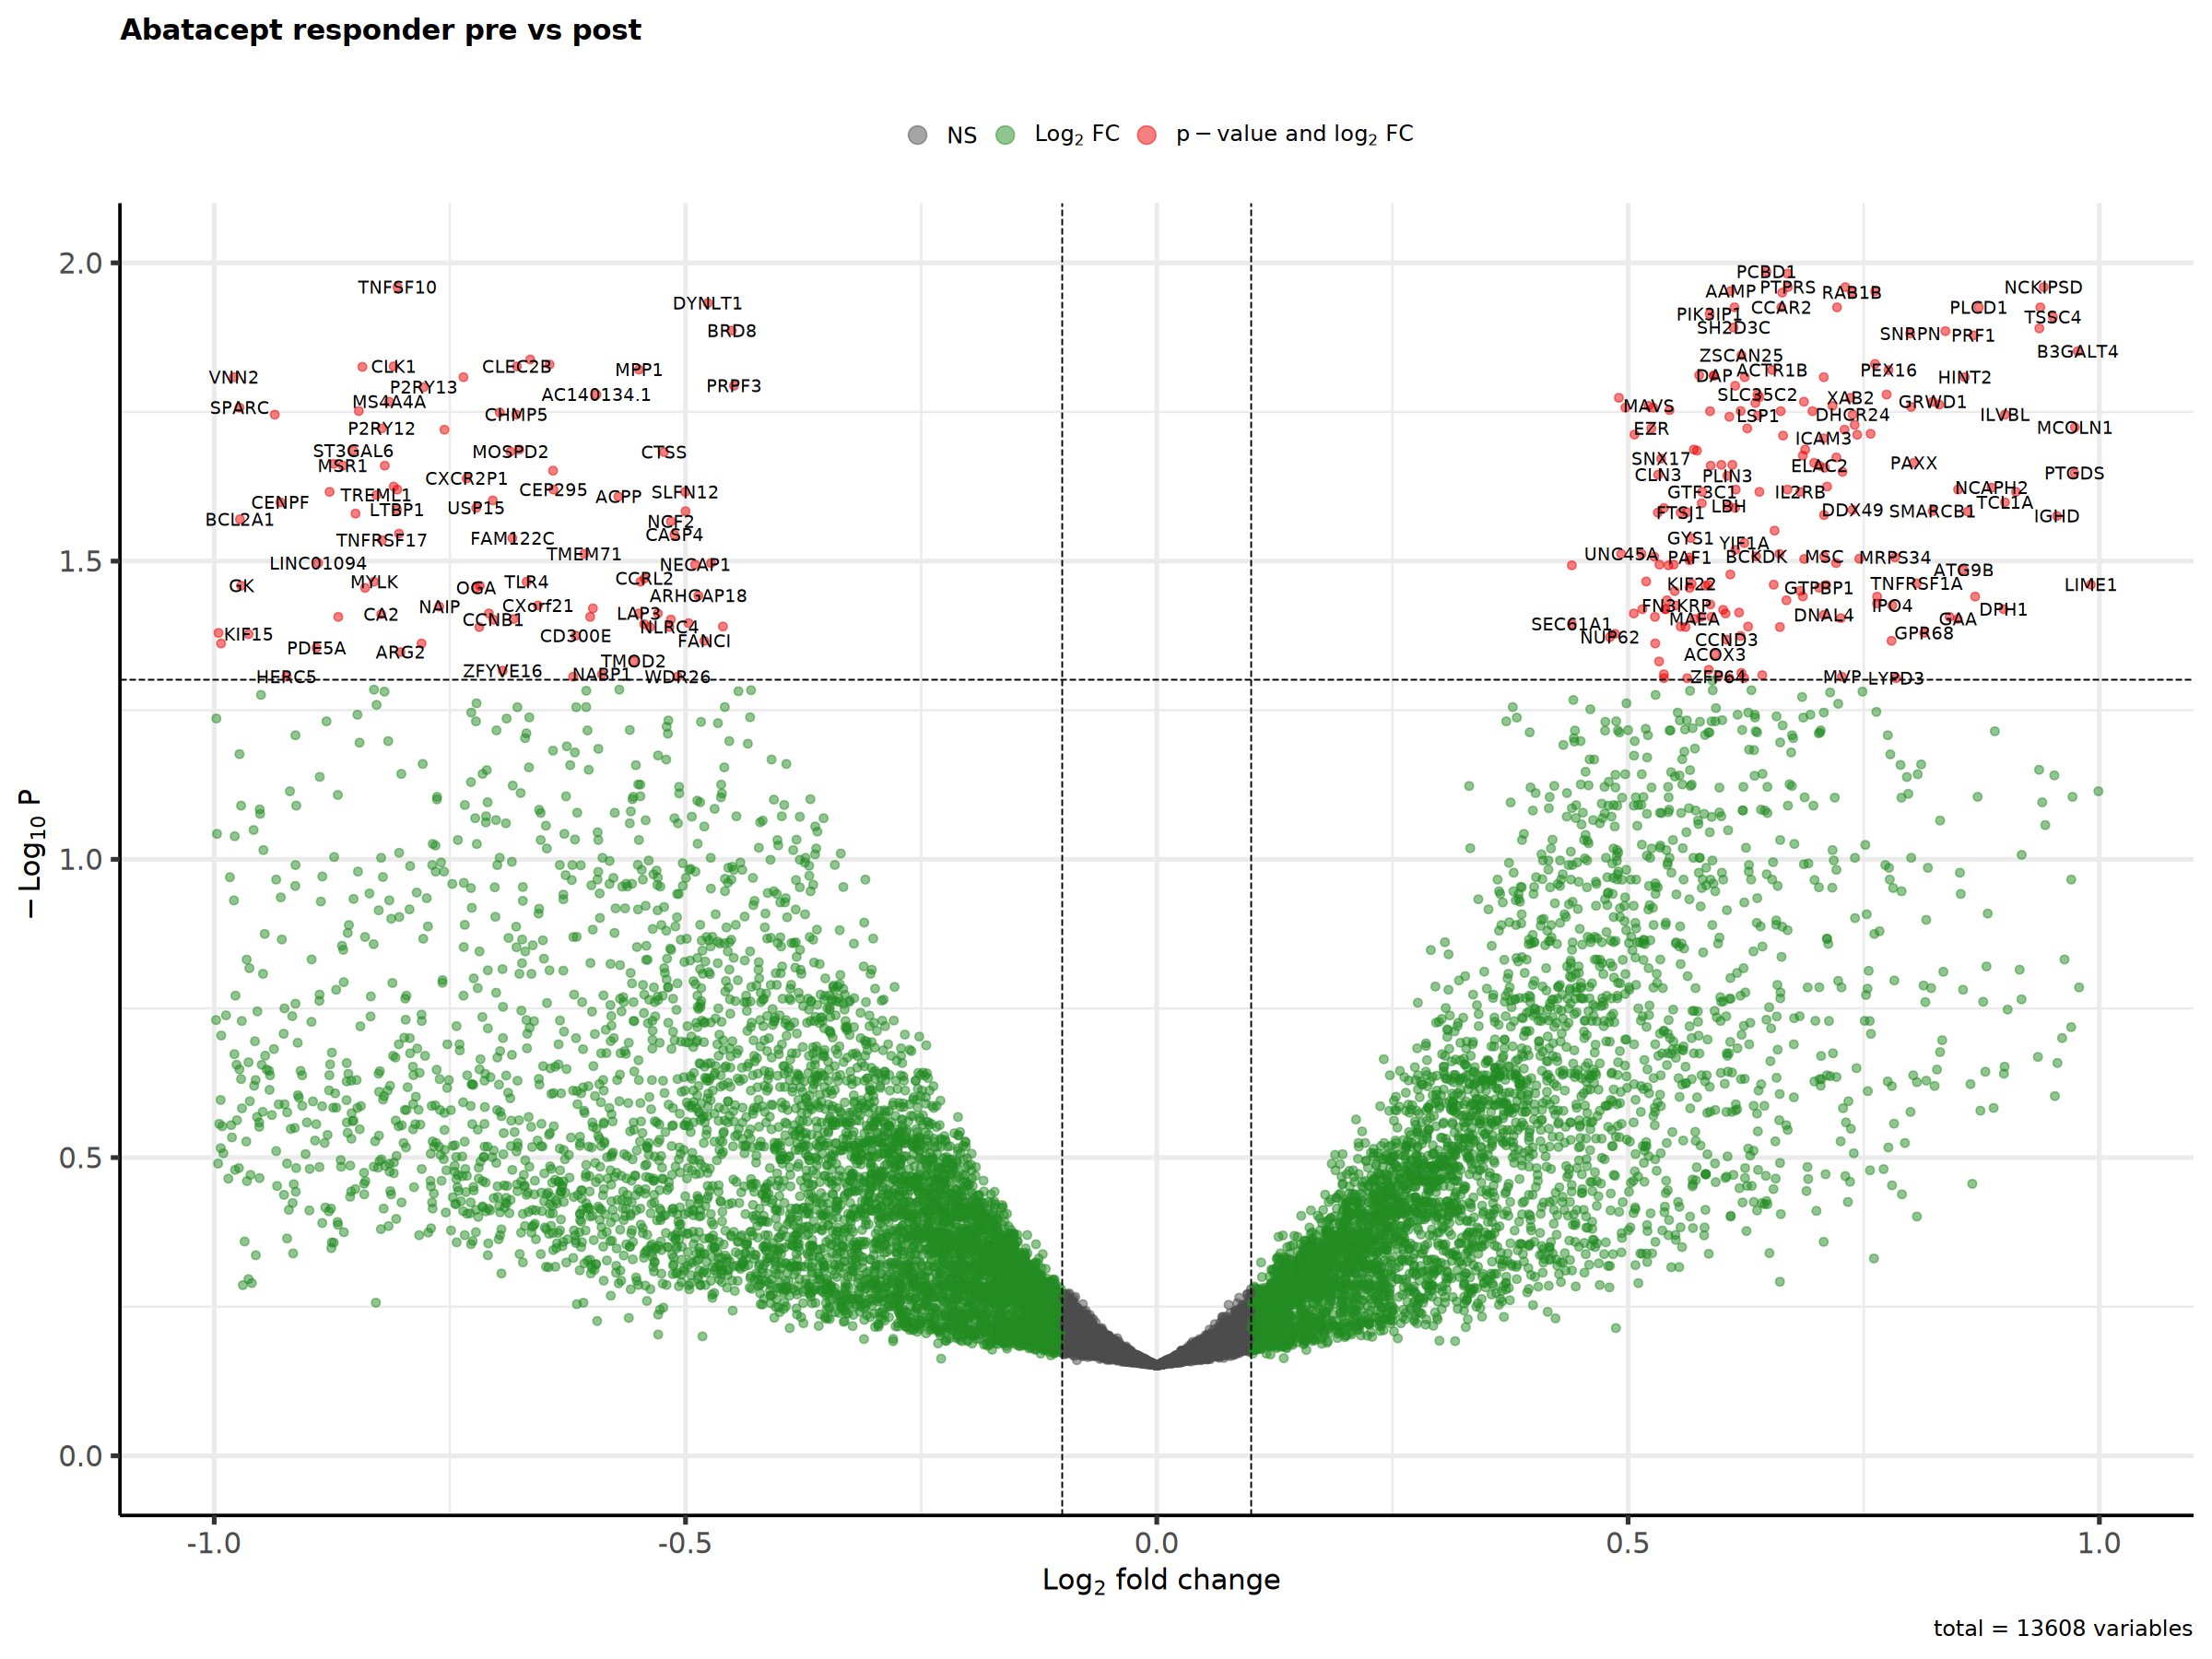

In [ ]:
# Plot the DA results for aim1
p1 <- EnhancedVolcano::EnhancedVolcano(dds_resp_res_tb,
    title = "Abatacept responder pre vs post",
    subtitle = "",
    lab = dds_resp_res_tb$gene,
    x = "log2FoldChange",
    y = "q_values",
    pCutoff = 0.05,
    FCcutoff = 0.1,
    pointSize = 2.0, # drawConnectors = TRUE,
    widthConnectors = 1.0,
    colConnectors = "black",
    arrowheads = FALSE,
    labSize = 4.0
) +
    xlim(c(-1, 1)) + ylim(0, 2)
p1
ggsave(file.path(fig_path, paste0(proj_name, "Abatacept_responders_prevspost_valcano_plot.png")),
    width = 8, height = 6
)


### load aim3 degs results and compared with the responder


In [ ]:
data_path <- "/home/jupyter/data/ra_longitudinal/output_results/certPro"
# load aim3 deg
aim3_degs <- read_csv(
    file.path(file.path(
        data_path,
        "ALTRA_AIM3_certpro_scRNA_Pseudobulk_AIFI_l3_mixed_models_time_result_750days.csv"
    )),
    show_col_types = FALSE
) %>%
    dplyr::rename("cell_type" = "celltype")


In [ ]:
# combine the deg results
abt_aim3_degs_comparison <- dds_resp_res_tb %>%
      full_join(aim3_degs,
            by = c("gene"),
            suffix = c("_abt", "_aim3")
      ) %>%
      dplyr::rename("pvalue_aim3" = "p.value") %>%
      filter(q_values_aim3 < 0.1 & # padj<0.1&
            !is.na(log2FoldChange)) %>%
      mutate(sig = case_when(
            q_values_abt <= 0.1 & q_values_aim3 <= 0.1 ~ "AbtSig&Aim3Sig",
            q_values_abt > 0.1 & q_values_aim3 <= 0.1 ~ "Aim3Sig",
            q_values_abt <= 0.1 & q_values_aim3 > 0.1 ~ "AbtSig",
            q_values_abt > 0.1 & q_values_aim3 > 0.1 ~ "No sig"
      )) %>%
      mutate(
            aim3_direction = if_else(estimate > 0, "aim3_up", "aim3_down"),
            abt_direction = if_else(log2FoldChange > 0, "abt_up", "abt_down")
      )
abt_aim3_degs_comparison %>% colnames()


[1] "gene"           "baseMean"       "log2FoldChange" "lfcSE"         
 [5] "stat"           "pvalue"         "q_values_abt"   "cell_type"     
 [9] "effect"         "group"          "term"           "estimate"      
[13] "std.error"      "statistic"      "df"             "pvalue_aim3"   
[17] "q_values_aim3"  "sig"            "aim3_direction" "abt_direction"

### run a HyperGeometric Enrichment test


In [ ]:
# check the deg counts
aim3_degs_counts <- aim3_degs %>%
    mutate(sig_0_1 = if_else(q_values < 0.1, "sig", "ns")) %>%
    group_by(cell_type) %>%
    mutate(total_genes = n()) %>%
    group_by(cell_type, sig_0_1) %>%
    summarise(counts = n(), total_genes = unique(total_genes))
aim3_degs_counts %>% filter(cell_type %in% c("Core naive CD4 T cell", "CM CD4 T cell"))


`summarise()` has grouped output by 'cell_type'. You can override using the
`.groups` argument.


cell_type,sig_0_1,counts,total_genes
<chr>,<chr>,<int>,<int>
CM CD4 T cell,ns,2785,5497
CM CD4 T cell,sig,2712,5497
Core naive CD4 T cell,ns,2299,4950
Core naive CD4 T cell,sig,2651,4950


In [ ]:
# use abt response genes as the reference
# check if the aim3 degs are significant enriched.
celltype_test <- "Core naive CD4 T cell"
aim3_sig_genes <- aim3_degs %>%
    filter(cell_type == celltype_test & q_values < 0.1) %>%
    pull(gene)
aim3_bg_genes <- aim3_degs %>%
    filter(cell_type == celltype_test) %>%
    pull(gene)

abt_sig_genes <- dds_resp_res_tb %>%
    filter(q_values < 0.1) %>%
    pull(gene)
abt_genes_list <- list("Abt_responder_genes" = abt_sig_genes)

hyp_obj <- hypeR(aim3_sig_genes, abt_genes_list,
    test = "hypergeometric", background = length(aim3_bg_genes), plotting = TRUE
)
hyp_obj


(hyp) 

  data: 
               label pval fdr signature geneset overlap background
 Abt_responder_genes    1   1      2651     965     237       4950
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [ ]:
# make a degs list per cell type
celltypes_test <- aim3_degs %>%
    filter(q_values < 0.1) %>%
    group_by(cell_type) %>%
    tally() %>%
    filter(n > 10) %>%
    pull(cell_type) %>%
    unique()
aim3_genes_list <- lapply(celltypes_test, function(x) {
    sig_genes <- aim3_degs %>%
        filter(cell_type == x & q_values < 0.1) %>%
        pull(gene)
    return(sig_genes)
})

names(aim3_genes_list) <- celltypes_test
# aim3_genes_list
abt_sig_genes <- dds_resp_res_tb %>%
    filter(q_values < 0.1) %>%
    pull(gene)
abt_bg_genes <- dds_resp_res_tb %>% pull(gene)

hyp_obj <- hypeR(abt_sig_genes, aim3_genes_list,
    test = "hypergeometric", background = length(abt_bg_genes), plotting = TRUE
)


In [ ]:
hyp_to_excel(hyp_obj, file_path = file.path(output_path, "pathways.xlsx"))


In [ ]:
## plot fig6E
hyp_obj$data


,label,pval,fdr,signature,geneset,overlap,background,hits
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<chr>
Core naive CD4 T cell,Core naive CD4 T cell,3.3e-05,0.0003,965,2651,237,13608,"AAMP , ABHD14A , ABHD14B , ACTG1 , ADD1 , ADGRE5 , ADRM1 , AIF1 , ALKBH7 , AP1M1 , APBB1 , APH1A , APRT , AQP3 , ARL2 , ARL6IP4 , ASAH1 , ATE1 , ATP2A3 , ATP6V0E2 , BACH1 , BLCAP , BRD8 , BRMS1 , BSG , C20orf27 , C7orf50 , C9orf16 , C9orf72 , CARD16 , CASP1 , CASP4 , CASP8 , CBWD5 , CCDC107 , CCDC12 , CD27 , CD320 , CD7 , CD81 , CD99 , CDK4 , CEP295 , CEP68 , CHMP5 , CIRBP , CLK1 , CLPP , COPE , COQ8A , CORO1A , COX5A , CRIP2 , CTSD , CUX1 , CXXC1 , CYBA , CYTH2 , DAP , DCTN1 , DDA1 , DENND1C , DGCR6L , DMTF1 , DPYD , DYNLT1 , E2F4 , EEF1D , EEFSEC , EIF3F , EIF3G , EIF4G1 , EIF5A , EMD , EZR , FAM111A , FAU , FKBP2 , FLT3LG , FTH1 , GADD45GIP1 , GBP1 , GBP2 , GON4L , GPAA1 , GPR108 , GUK1 , GYPC , GZMM , HDAC3 , HINT2 , HK1 , HLA-E , HMGA1 , HPS1 , HSPB1 , ICAM3 , IL27RA , IL4R , ISCU , ITGB2 , ITGB7 , ITM2C , JTB , KIF22 , KLHDC3 , LAGE3 , LAT , LCK , LGALS8 , LIMD2 , LMAN2 , LRPAP1 , LSP1 , LTB , LUC7L3 , LYPLA2 , LYST , MAD1L1 , MAL , MCRIP1 , METTL26 , MFSD8 , MITD1 , MPG , MRPL12 , MRPL28 , MRPL41 , MRPL54 , MRPS12 , MRPS2 , MRPS26 , MYDGF , MYH9 , MZT2B , N4BP2L2 , NABP1 , NAIP , NAXE , NDUFB11 , NDUFV1 , NECAP1 , NHP2 , NKTR , NME3 , NOSIP , NUDT16L1 , OGA , PAXBP1 , PAXX , PCIF1 , PEX16 , PFN1 , PGLS , PICALM , PLEKHB1 , POLD2 , POLR2E , POMP , PPIL2 , PPP4C , PRPF3 , PRPF39 , PSMA4 , PSMF1 , PTPMT1 , PUF60 , R3HCC1 , RAB1B , RAB5C , RAD23A , RALY , RBM25 , RBM39 , RBM6 , RFTN1 , RNH1 , RPL13 , RPL18 , RPL18A , RPLP2 , RPS2 , SAMD9 , SAMD9L , SART3 , SCAMP2 , SCAND1 , SDF2L1 , SF3B1 , SF3B4 , SGF29 , SIGIRR , SIVA1 , SLC25A39 , SLC3A2 , SMDT1 , SNF8 , SNRPB , SNRPN , SNX17 , SPTBN1 , SQSTM1 , SRP68 , SRSF7 , SSNA1 , SUMO3 , SURF4 , SUSD3 , SYNGR2 , SZRD1 , TBC1D10A , TECR , TIMM13 , TMED3 , TMED9 , TMEM134 , TMEM167A , TNFRSF14 , TRAPPC6A , TRIM22 , TSPO , TSSC4 , TUFM , TWF2 , UBE4A , UBXN1 , UNC119 , USP15 , VPS51 , WDR26 , WDR46 , ZAP70 , ZDHHC12 , ZDHHC6 , ZNF511 , ZNF581 , ZNF83"
CM CD4 T cell,CM CD4 T cell,5.0e-04,0.0022,965,2712,233,13608,"ABHD14A , ACO2 , ACTG1 , ADD1 , ADGRE5 , ADRM1 , AIF1 , ALKBH7 , ANXA6 , APH1A , APRT , AQP3 , ARL6IP4 , ATP6AP1 , ATP6V0E2 , BACH1 , BAZ2B , BRD8 , BRMS1 , BSG , C20orf27 , C6orf47 , C7orf50 , C9orf16 , CALCOCO2 , CARD16 , CASP1 , CASP4 , CASP8 , CBR3 , CCDC107 , CCDC12 , CD27 , CD320 , CD81 , CD99 , CEP68 , CHID1 , CHMP1A , CHMP5 , CHMP6 , CHTF8 , CLEC2B , CLK1 , CLPP , COPE , COQ8A , CORO1A , COX5A , CRIP2 , CUX1 , CXCR3 , CXXC1 , CYBA , DAP , DCTN1 , DGCR6L , DMTF1 , DYNLT1 , E2F4 , EEF1D , EEFSEC , EIF3F , EIF3G , EIF4G1 , EIF5A , EMD , EZR , FAM111A , FAU , FKBP2 , FLT3LG , FN3KRP , FTH1 , FXN , GADD45GIP1 , GNPTG , GON4L , GPR108 , GUK1 , GYPC , GZMM , HINT2 , HIRIP3 , HLA-E , HPS1 , HSPB1 , ICAM3 , IL27RA , ISCU , ITGB2 , ITGB7 , ITM2C , JTB , KIAA1109 , KLF2 , LAGE3 , LBH , LCK , LGALS3BP , LIMD2 , LMAN2 , LRPAP1 , LSP1 , LTB , LUC7L3 , LYST , MAD1L1 , MAL , MAP1LC3B , MAVS , MCRIP1 , METTL26 , MFSD8 , MPG , MRPL12 , MRPL28 , MRPL41 , MRPL54 , MRPS12 , MRPS2 , MRPS26 , MSL1 , MYDGF , MYH9 , MZT2B , N4BP2L2 , NABP1 , NAIP , NAXE , NDUFB11 , NDUFV1 , NHP2 , NKTR , NME3 , NOC2L , NOSIP , NSUN2 , NUDT16L1 , NUP210 , NXT1 , OGA , P4HB , PAXBP1 , PAXX , PCBD1 , PCIF1 , PEPD , PEX16 , PFKL , PFN1 , PGLS , PI16 , PICALM , PLIN3 , PNISR , POLR2E , POMP , PPIL2 , PPP4C , PRPF3 , PRPF31 , PRPF39 , PSMF1 , PTPMT1 , PTPN7 , PUF60 , RAB5C , RAD23A , RASA3 , RBM25 , RBM39 , RBM6 , RHBDD2 , RPL13 , RPL18 , RPL18A , RPLP2 , RPS2 , S1PR4 , SAMD9 , SCAND1 , SDF2L1 , SF3B1 , SF3B4 , SGF29 , SIGIRR , SIVA1 , SLC25A39 , SLC39A3 , SLC3A2 , SMDT1 , SNAP47 , SNF8 , SNRPB , SNRPN , SNX17 , SPTBN1 , SQSTM1 , SRRT , SRSF7 , SSNA1 , SURF4 , SYNGR2 , TANK , TIMM13 , TMED3 , TMED9 , TMEM134 , TNFRSF14 , TRAPPC6A , TRIM22 , TRIM28 , TRPC4AP , TSPO , TSSC4 , TUFM , TUT7 , TWF2 , UBXN1 , UCKL1 , UNC119 , USP15 , VPS51

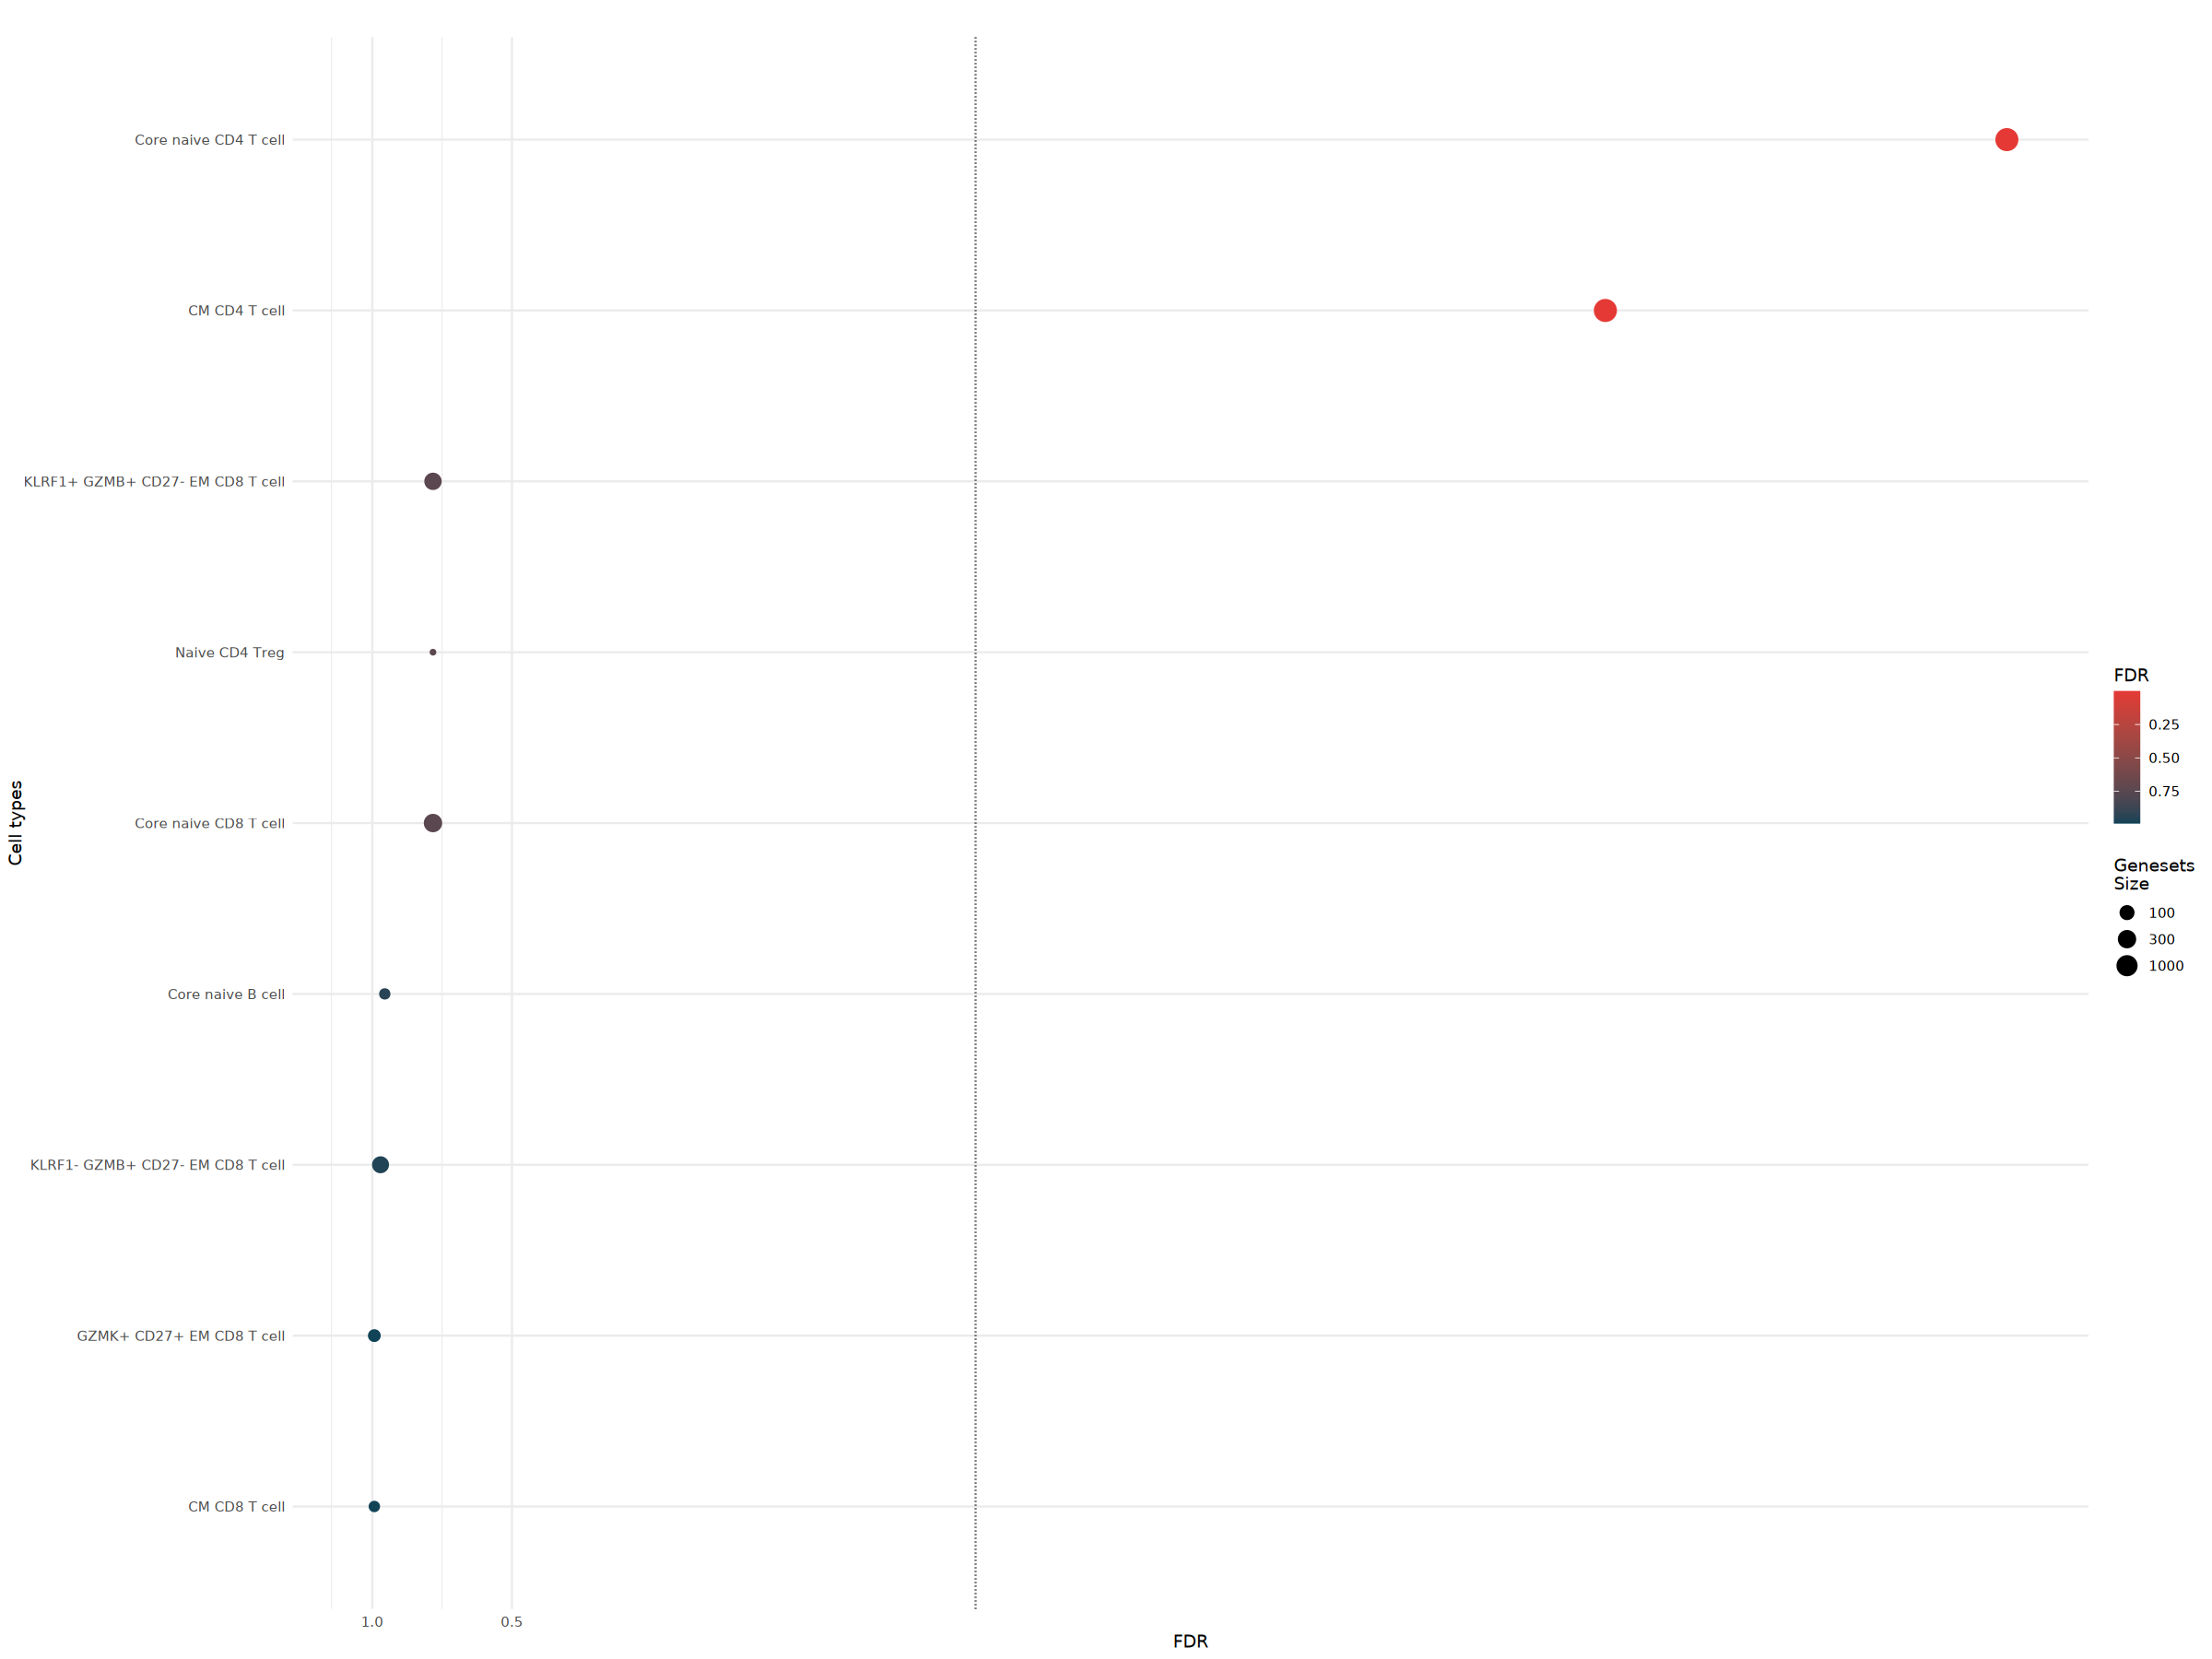

In [ ]:
p1 <- hyp_dots(hyp_obj) + theme_minimal() + xlab("Cell types")
p1
ggsave(file.path(fig_path, paste0(proj_name, "gene_signature_abt_responder.pdf")), width = 6, height = 4)


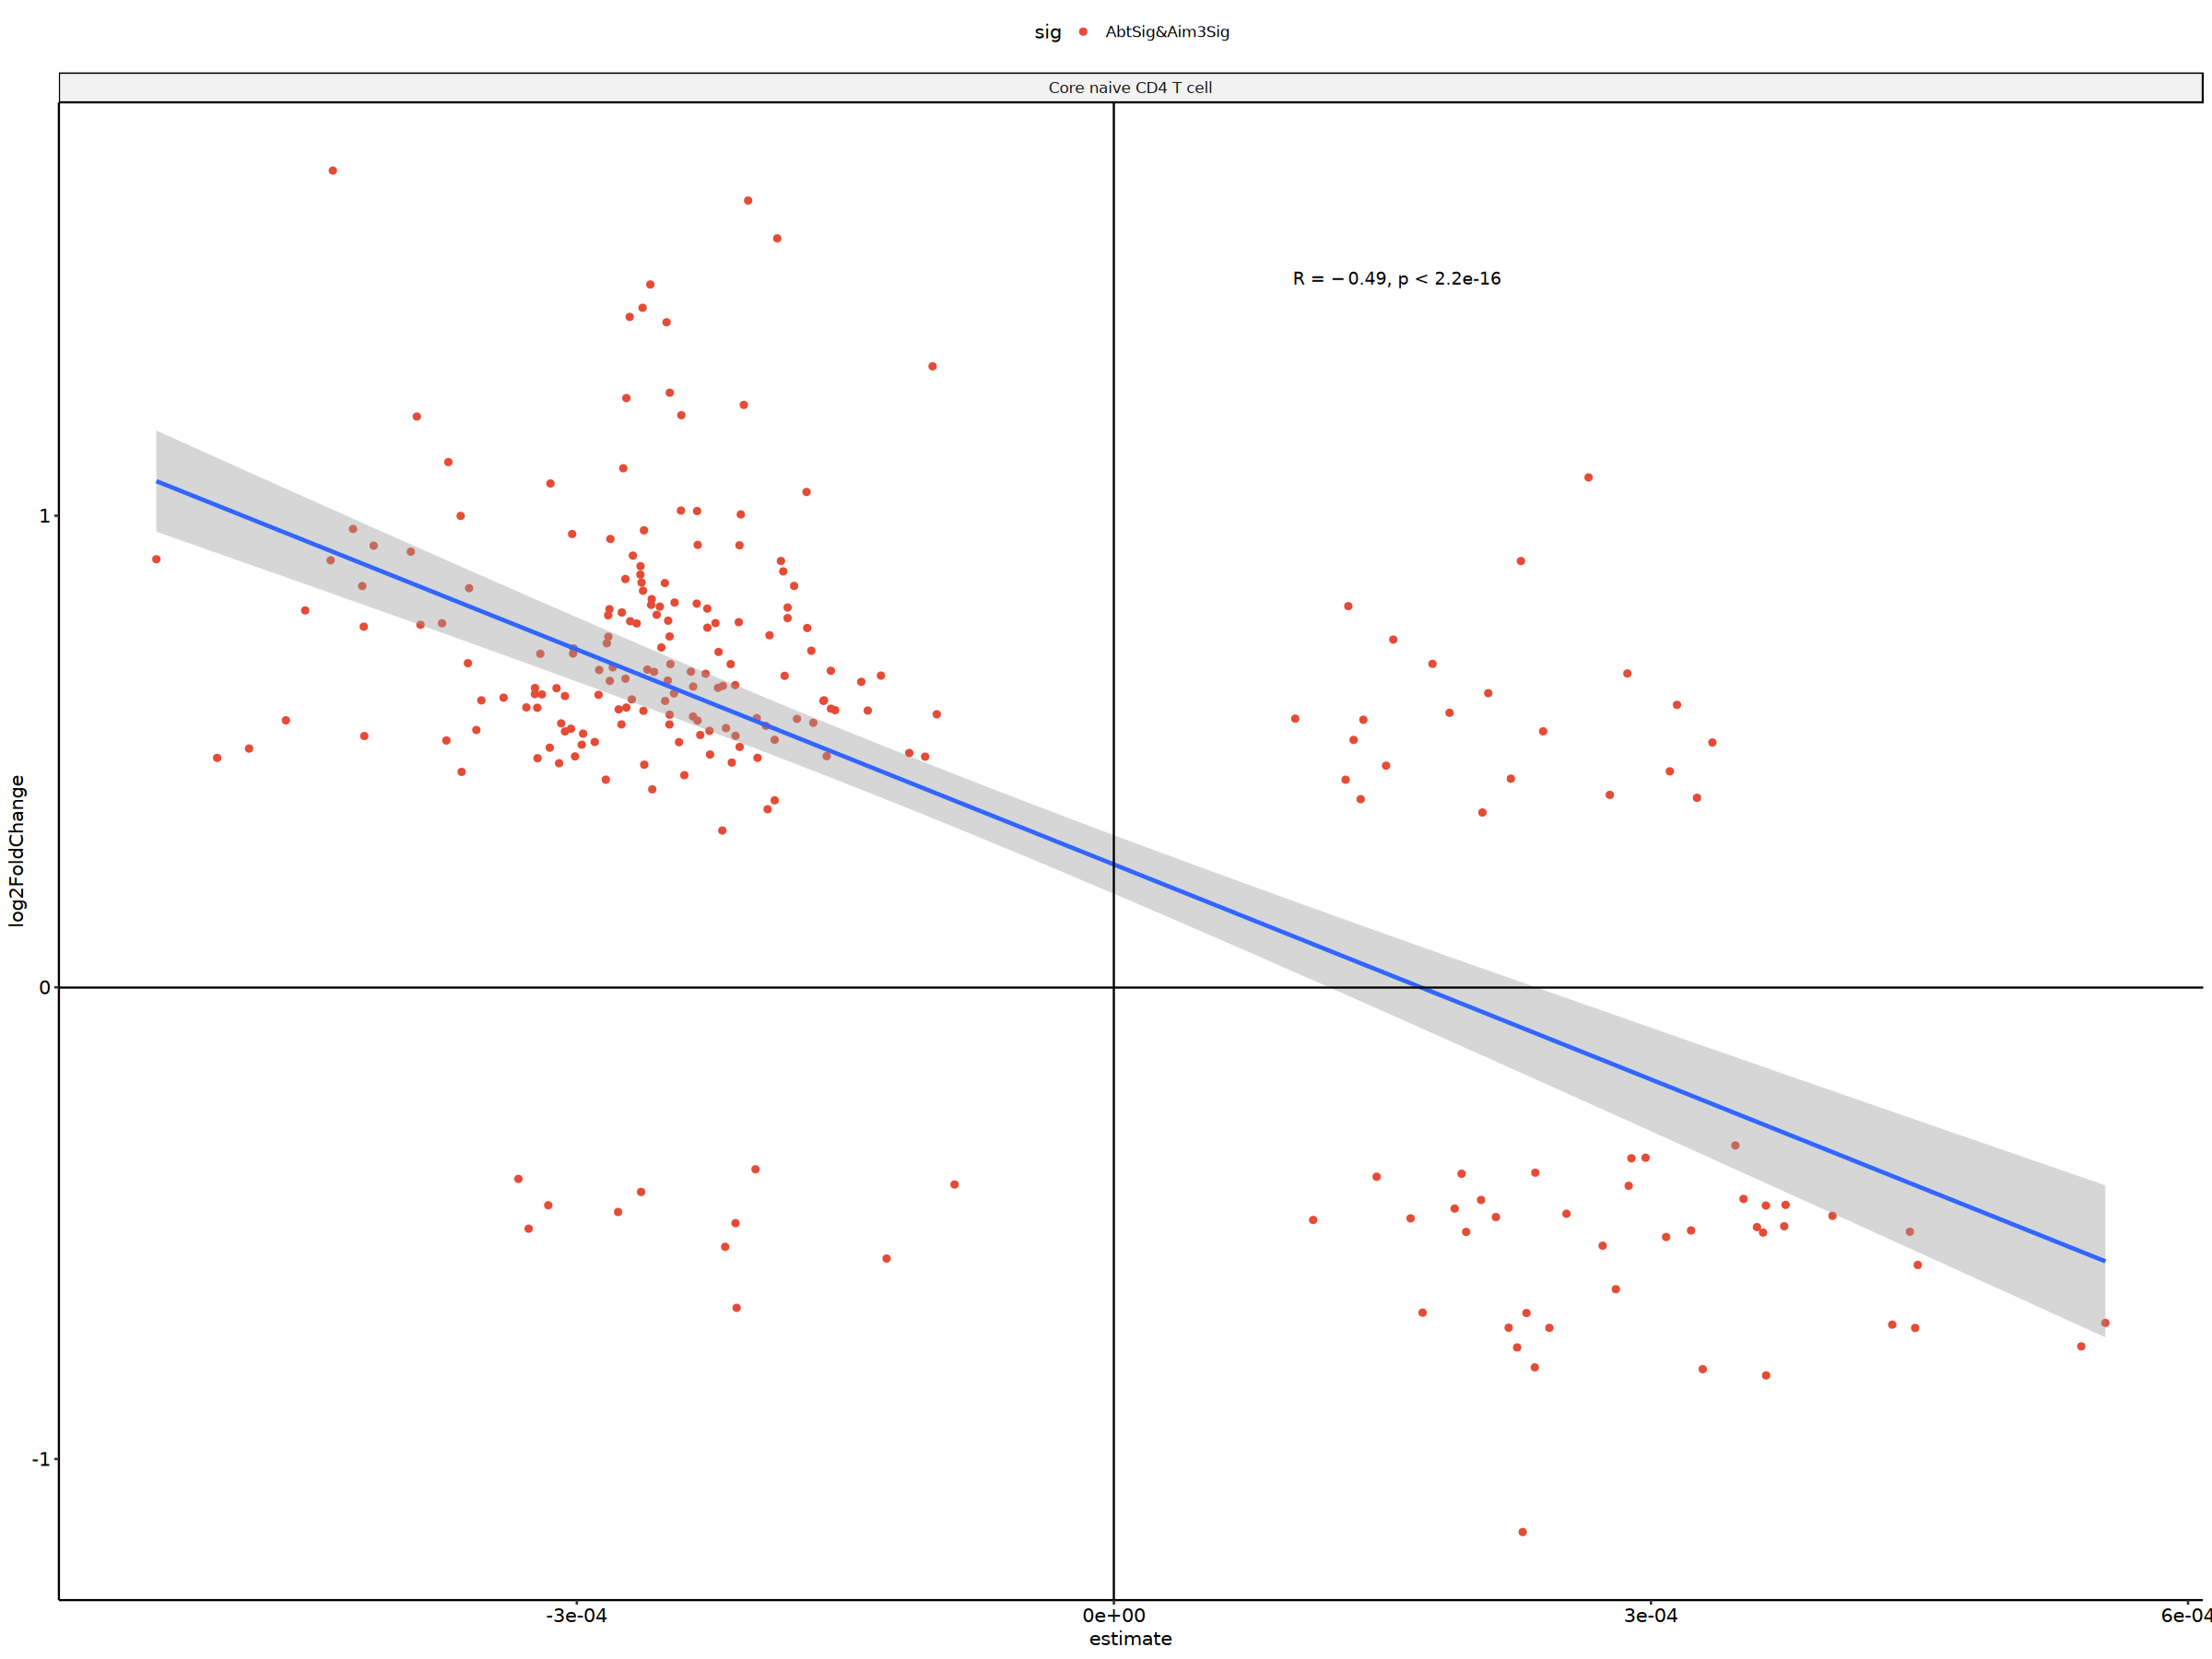

In [ ]:
# plot the significant genes
abt_aim3_degs_comparison %>%
    filter(q_values_abt < 0.1) %>%
    filter(cell_type %in% c("Core naive CD4 T cell")) %>%
    ggplot(aes(y = log2FoldChange, x = estimate)) +
    geom_point(aes(color = sig)) +
    # ggrepel::geom_text_repel(aes(label=gene),
    #                         ) +
    stat_smooth(
        method = "lm",
        formula = y ~ x,
        geom = "smooth"
    ) +
    geom_vline(xintercept = 0) +
    geom_hline(yintercept = 0) +
    ggpubr::stat_cor(method = "spearman", label.x = 0.0001, label.y = 1.5) +
    facet_wrap(vars(cell_type)) +
    scale_color_manual(values = npg_color) +
    theme_pubr()
ggsave(file.path(fig_path, paste0(proj_name, "abecetpt_responder_Aim3_deg_cd4na_logfc_cor_plot.pdf")),
    width = 4, height = 4
)


Warning message:
“ggrepel: 2630 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2591 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


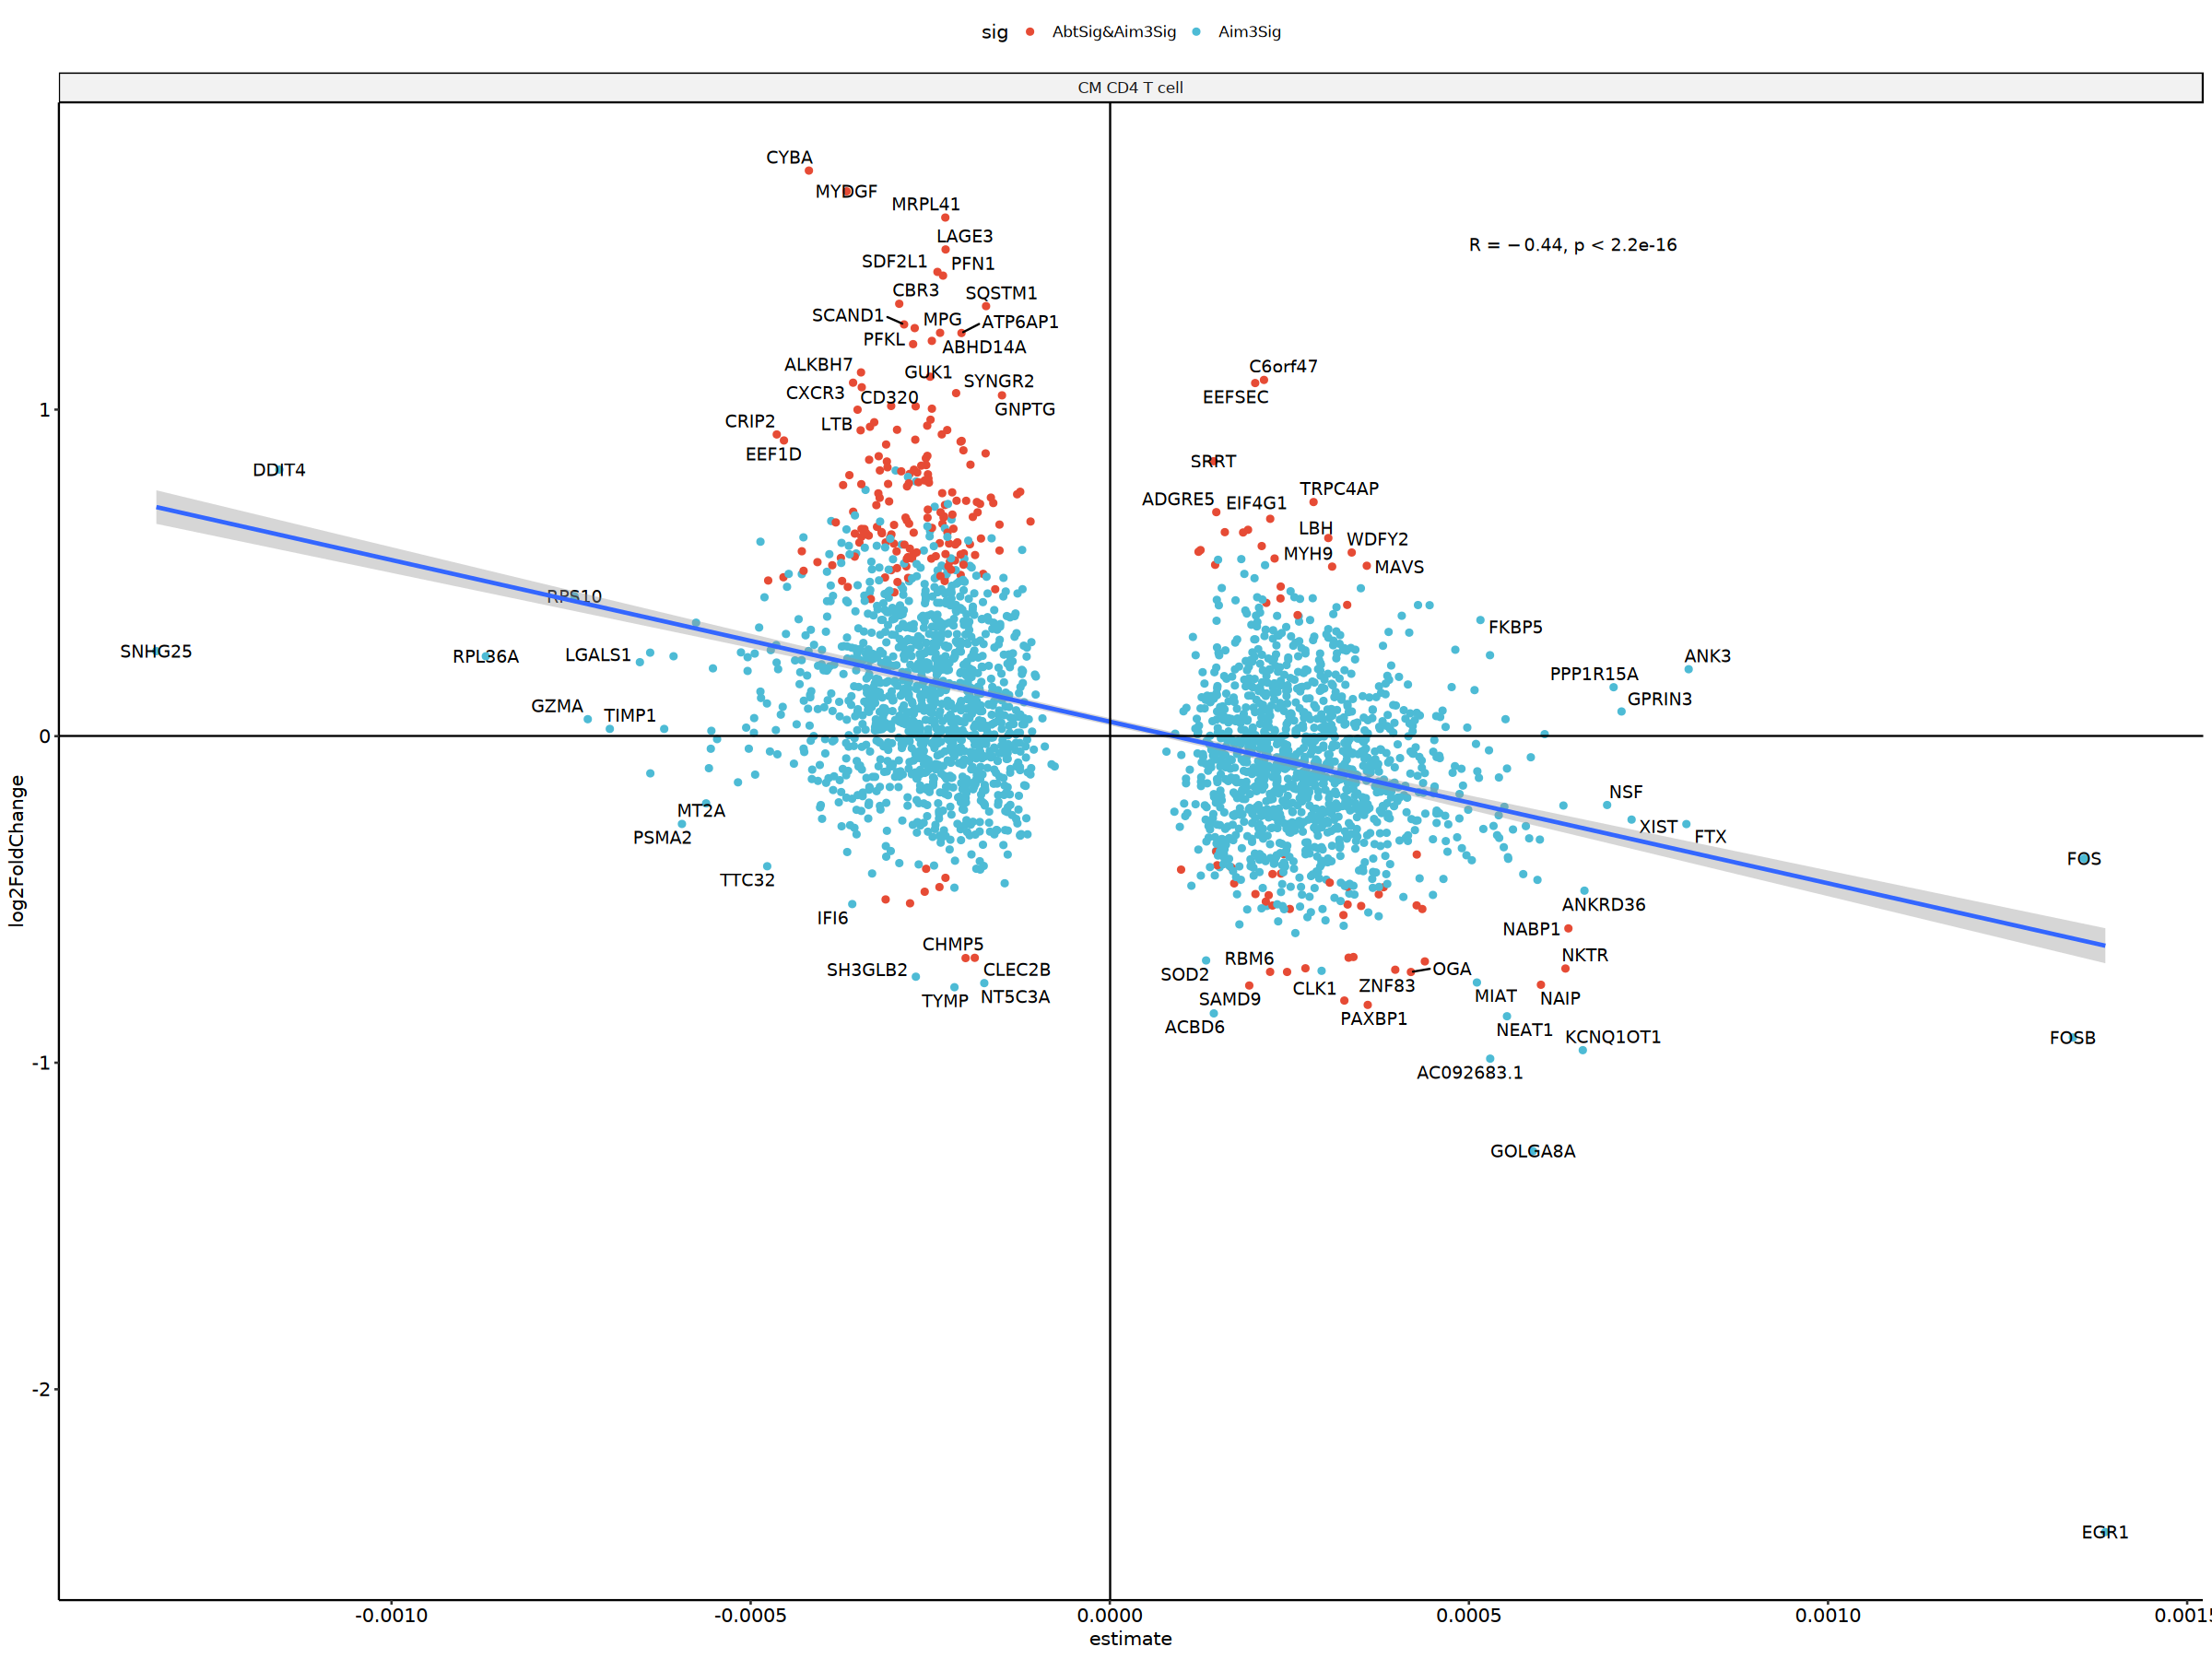

In [ ]:
# plot the significant genes
abt_aim3_degs_comparison %>%
    filter(cell_type %in% c("CM CD4 T cell")) %>%
    ggplot(aes(y = log2FoldChange, x = estimate)) +
    geom_point(aes(color = sig)) +
    ggrepel::geom_text_repel(aes(label = gene), ) +
    stat_smooth(
        method = "lm",
        formula = y ~ x,
        geom = "smooth"
    ) +
    geom_vline(xintercept = 0) +
    geom_hline(yintercept = 0) +
    ggpubr::stat_cor(method = "spearman", label.x = 0.0005, label.y = 1.5) +
    facet_wrap(vars(cell_type)) +
    scale_color_manual(values = npg_color) +
    theme_pubr()
ggsave(
    file.path(fig_path, paste0(
        proj_name,
        "abecetpt_responder_Aim3_deg_cd4cm_logfc_cor_plot.png"
    )),
    width = 16, height = 12
)


### run mcnemar test


In [ ]:
# run mcnemar test
abt_aim3_degs_comparison_counts <- abt_aim3_degs_comparison %>%
    filter(q_values_abt < 0.1) %>%
    group_by(cell_type, aim3_direction, abt_direction) %>%
    tally() %>%
    ungroup()
celltypes_test <- abt_aim3_degs_comparison_counts %>%
    group_by(cell_type) %>%
    tally() %>%
    filter(n >= 4) %>%
    pull(cell_type)
celltypes_test

mcnemar_res <- abt_aim3_degs_comparison_counts %>%
    filter(cell_type %in% celltypes_test) %>%
    group_by(cell_type) %>%
    group_modify(~ run_mcnemar_test(.x))
# cont_counts = abt_aim3_degs_comparison_counts%>%filter(cell_type=='Core_naive_CD4_T_cell')%>%
#     pivot_wider(id_cols = aim3_direction, names_from = abt_direction , values_from = n)
# sex_counts = aim1_filedesc_fl%>%group_by(status, subject.biologicalSex)%>%tally()%>%
#     pivot_wider(id_cols = subject.biologicalSex, names_from = status , values_from = n)
# sex_counts
mcnemar_res


[1] "CM CD4 T cell"                    "Core naive CD4 T cell"           
[3] "KLRF1+ GZMB+ CD27- EM CD8 T cell" "KLRF1- GZMB+ CD27- EM CD8 T cell"

cell_type,n,statistic,df,p,p.signif,method
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
CM CD4 T cell,233,79.84653,1,4.05e-19,****,McNemar test
Core naive CD4 T cell,237,74.16176,1,7.20e-18,****,McNemar test
KLRF1+ GZMB+ CD27- EM CD8 T cell,16,1.50000,1,2.21e-01,ns,McNemar test
KLRF1- GZMB+ CD27- EM CD8 T cell,11,3.12500,1,7.71e-02,ns,McNemar test


In [ ]:
abt_aim3_degs_comparison_counts %>%
    filter(cell_type %in% c("CM CD4 T cell")) %>%
    pivot_wider(
        id_cols = c(cell_type, aim3_direction),
        names_from = abt_direction, values_from = n
    )


cell_type,aim3_direction,abt_down,abt_up
<chr>,<chr>,<int>,<int>
CM CD4 T cell,aim3_down,8,165
CM CD4 T cell,aim3_up,37,23


In [ ]:
# GGally::ggtable(abt_aim3_degs_comparison %>% filter(q_values_abt<0.1)%>%
#     filter(cell_type%in%c('Core_naive_CD4_T_cell', 'CM_CD4_T_cell')),
#         "cell_type", c("aim3_direction", "abt_direction"))


Warning message:
“ggrepel: 2638 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 176 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2587 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 199 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2638 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 178 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2587 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 200 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


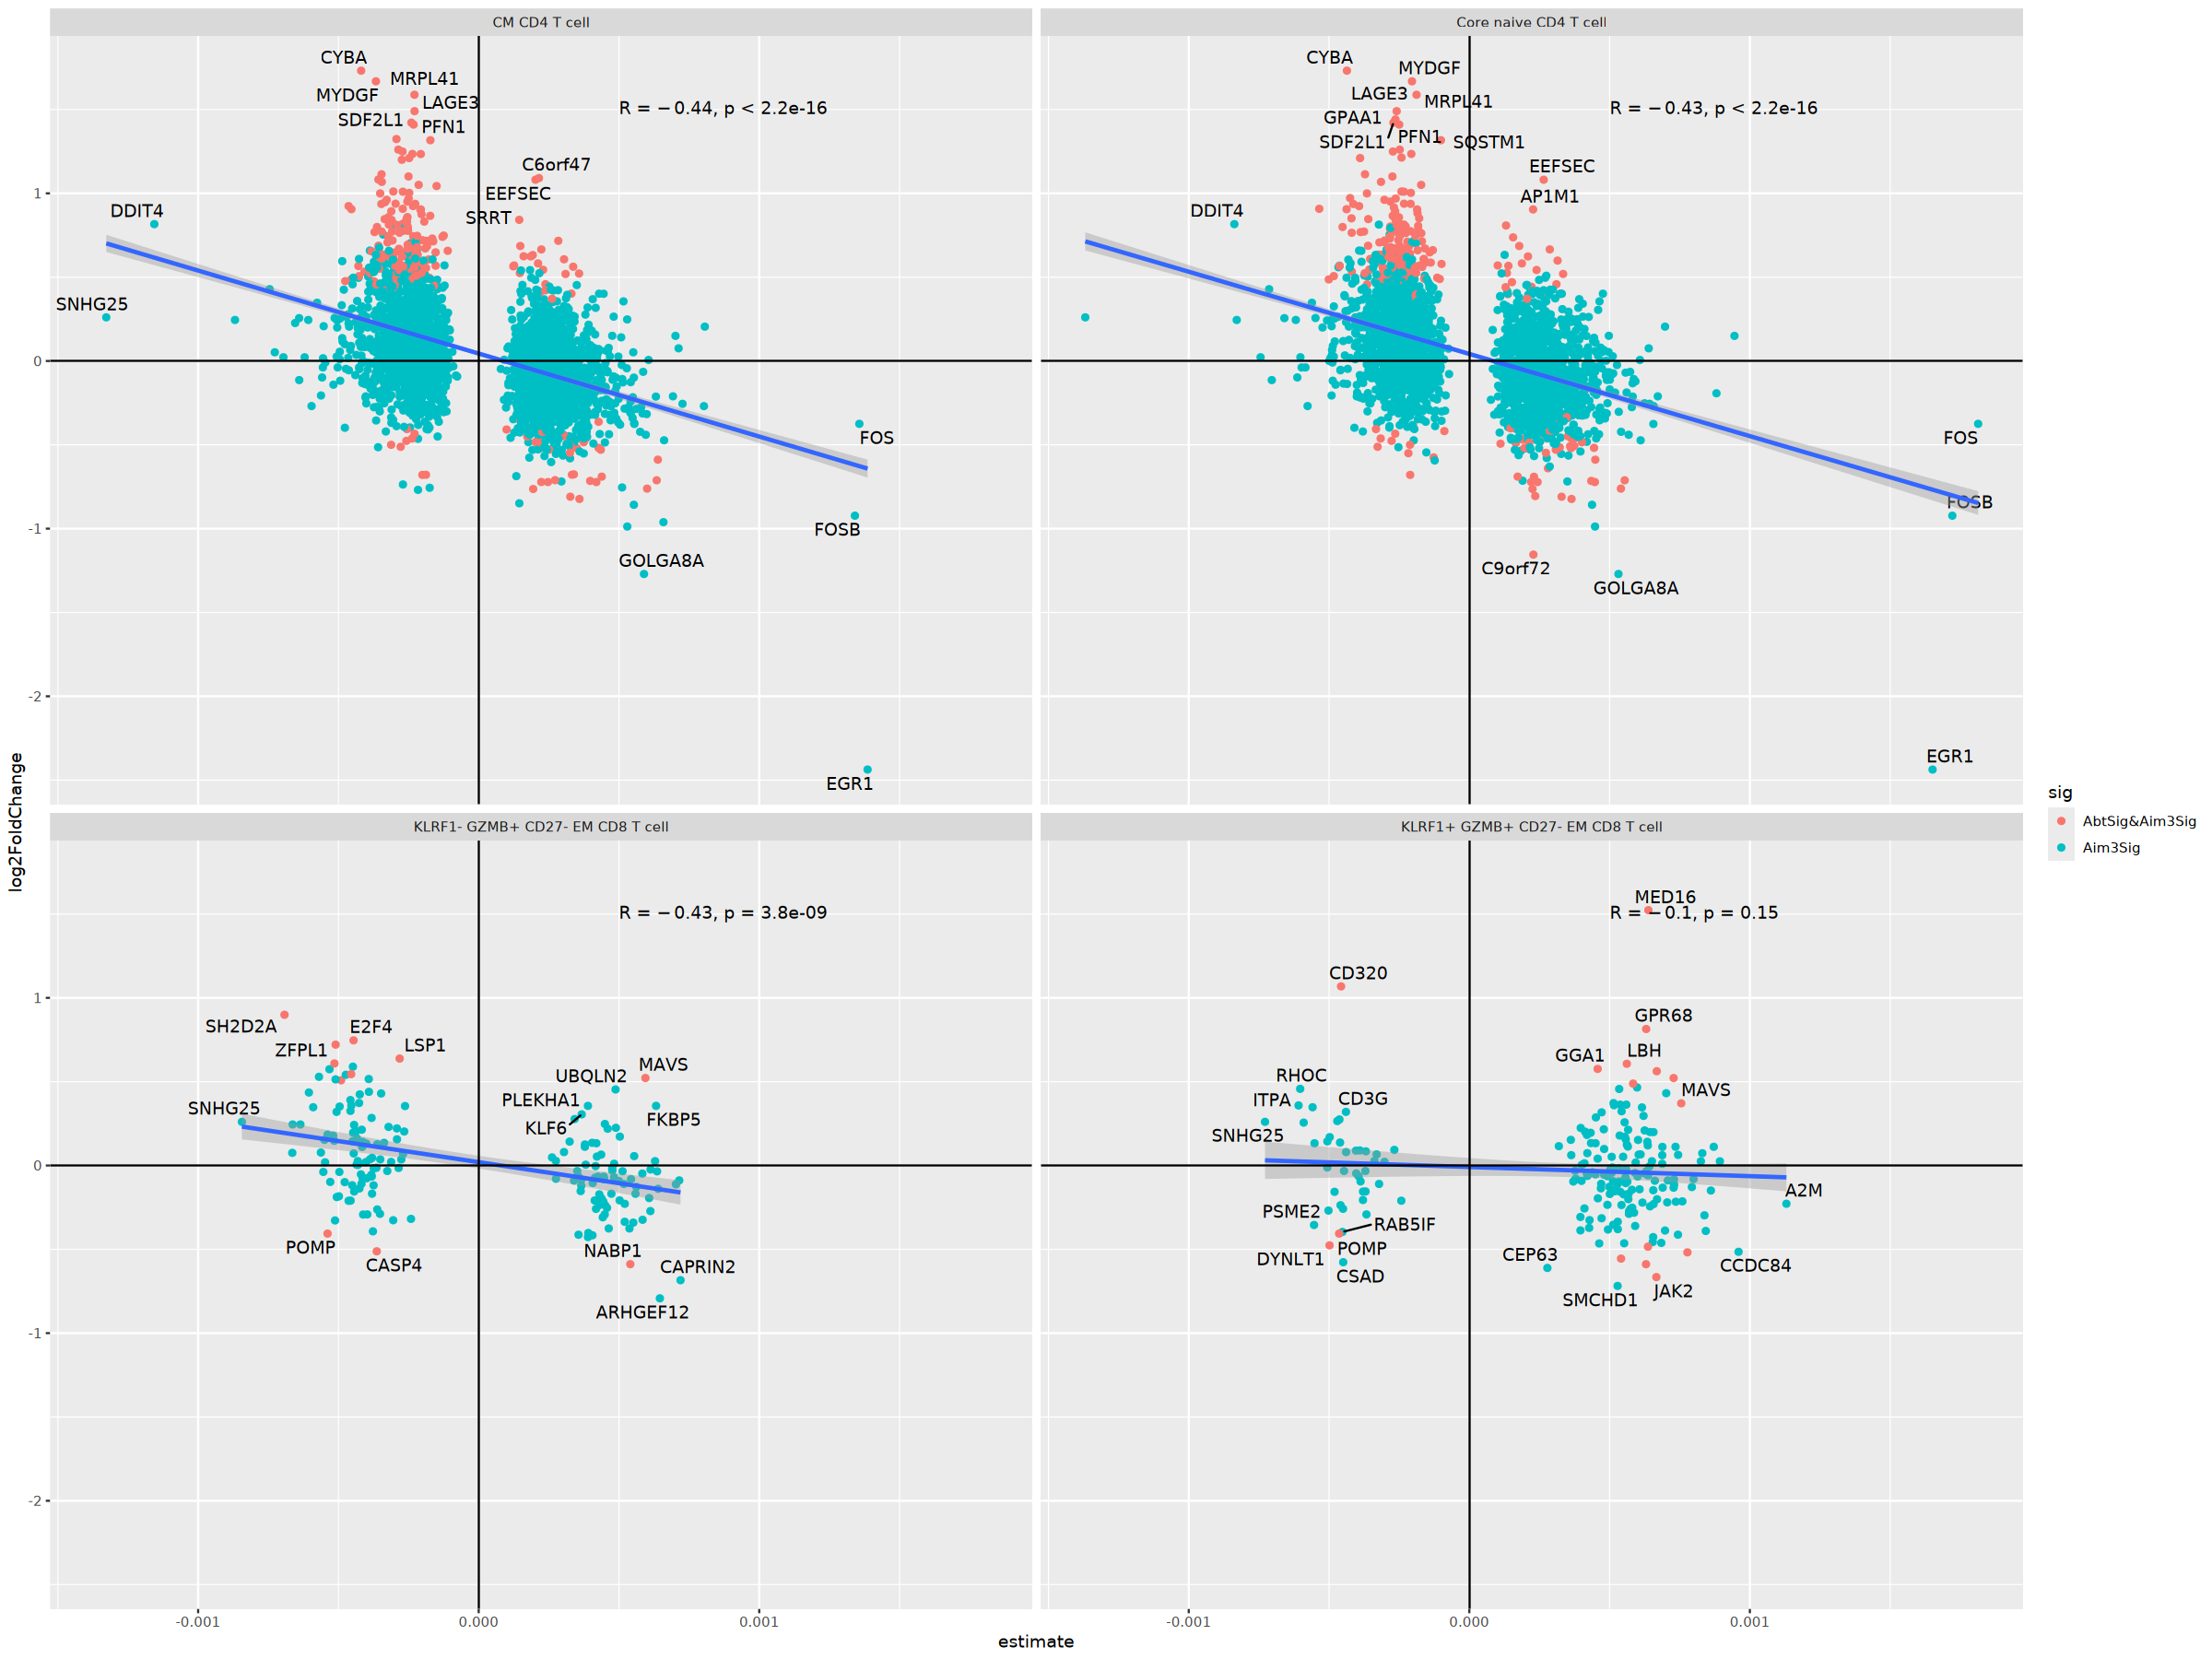

In [ ]:
abt_aim3_degs_comparison %>%
    filter(cell_type %in% celltypes_test) %>%
    ggplot(aes(y = log2FoldChange, x = estimate)) +
    geom_point(aes(color = sig)) +
    ggrepel::geom_text_repel(aes(label = gene)) +
    stat_smooth(
        method = "lm",
        formula = y ~ x,
        geom = "smooth"
    ) +
    geom_vline(xintercept = 0) +
    geom_hline(yintercept = 0) +
    ggpubr::stat_cor(method = "spearman", label.x = 0.0005, label.y = 1.5) +
    facet_wrap(vars(cell_type))
ggsave(file.path(fig_path, paste0("abecetpt_Aim3_deg_all_celltype_logfc_cor_plot.png")),
    width = 8, height = 6
)


# analyze non-responder


In [ ]:
# seperate responder and non-responder and construct the deseq2 object
# non-responder
nonres_sample <- sampleTable %>% filter(response == "Non_responder")
nonres_count <- counts[, colnames(counts) %in% rownames(nonres_sample)]
# res_sample
dds_nonresp <- DESeqDataSetFromMatrix(round(nonres_count), nonres_sample, ~ patient + time)


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


In [ ]:
smallestGroupSize <- 15
keep <- rowSums(counts(dds_nonresp) >= 10) >= smallestGroupSize
dds_nonresp <- dds_nonresp[keep, ]
dds_nonresp


class: DESeqDataSet 
dim: 13275 30 
metadata(1): version
assays(1): counts
rownames(13275): DPM1 SCYL3 ... AC133644.2 AC064836.3
rowData names(0):
colnames(30): NR01_0M NR01_3M ... NR15_0M NR15_3M
colData names(4): sample patient time response

In [ ]:
dds_nonresp$time <- factor(dds_nonresp$time, levels = c("0M", "3M"))


In [ ]:
# run deseq2 in non-responder
dds_nonresp <- DESeq(dds_nonresp)
dds_nonresp_res <- results(dds_nonresp)
dds_nonresp_res_tb <- dds_nonresp_res %>% as_tibble(rownames = "gene")


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [ ]:
# # calculate the qvalues
dds_nonresp_res_tb <- dds_nonresp_res_tb %>%
    mutate(q_values = qvalue::qvalue(pvalue)$qvalues) %>%
    select(-padj)
dds_nonresp_res_tb %>% head()


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DPM1,379.14259,-0.05712159,0.1720638,-0.3319792,0.73990500,0.9552337
SCYL3,343.65831,0.02574844,0.1391630,0.1850236,0.85321051,0.9655959
C1orf112,71.51417,-0.04306472,0.2046950,-0.2103848,0.83336736,0.9647510
FGR,5741.95475,-0.12543644,0.2116220,-0.5927381,0.55335644,0.9272609
CFH,63.91320,0.17075121,0.2480037,0.6885025,0.49113637,0.9160209
FUCA2,265.58381,-0.41320596,0.2245246,-1.8403593,0.06571551,0.6199254


In [ ]:
# save the deg table
dds_nonresp_res_tb %>% write_csv(file.path(output_path, paste0(proj_name, "nonresponder_pre_post_degs.csv")))


In [ ]:
dds_nonresp_res_tb %>% filter(is.na(q_values))


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


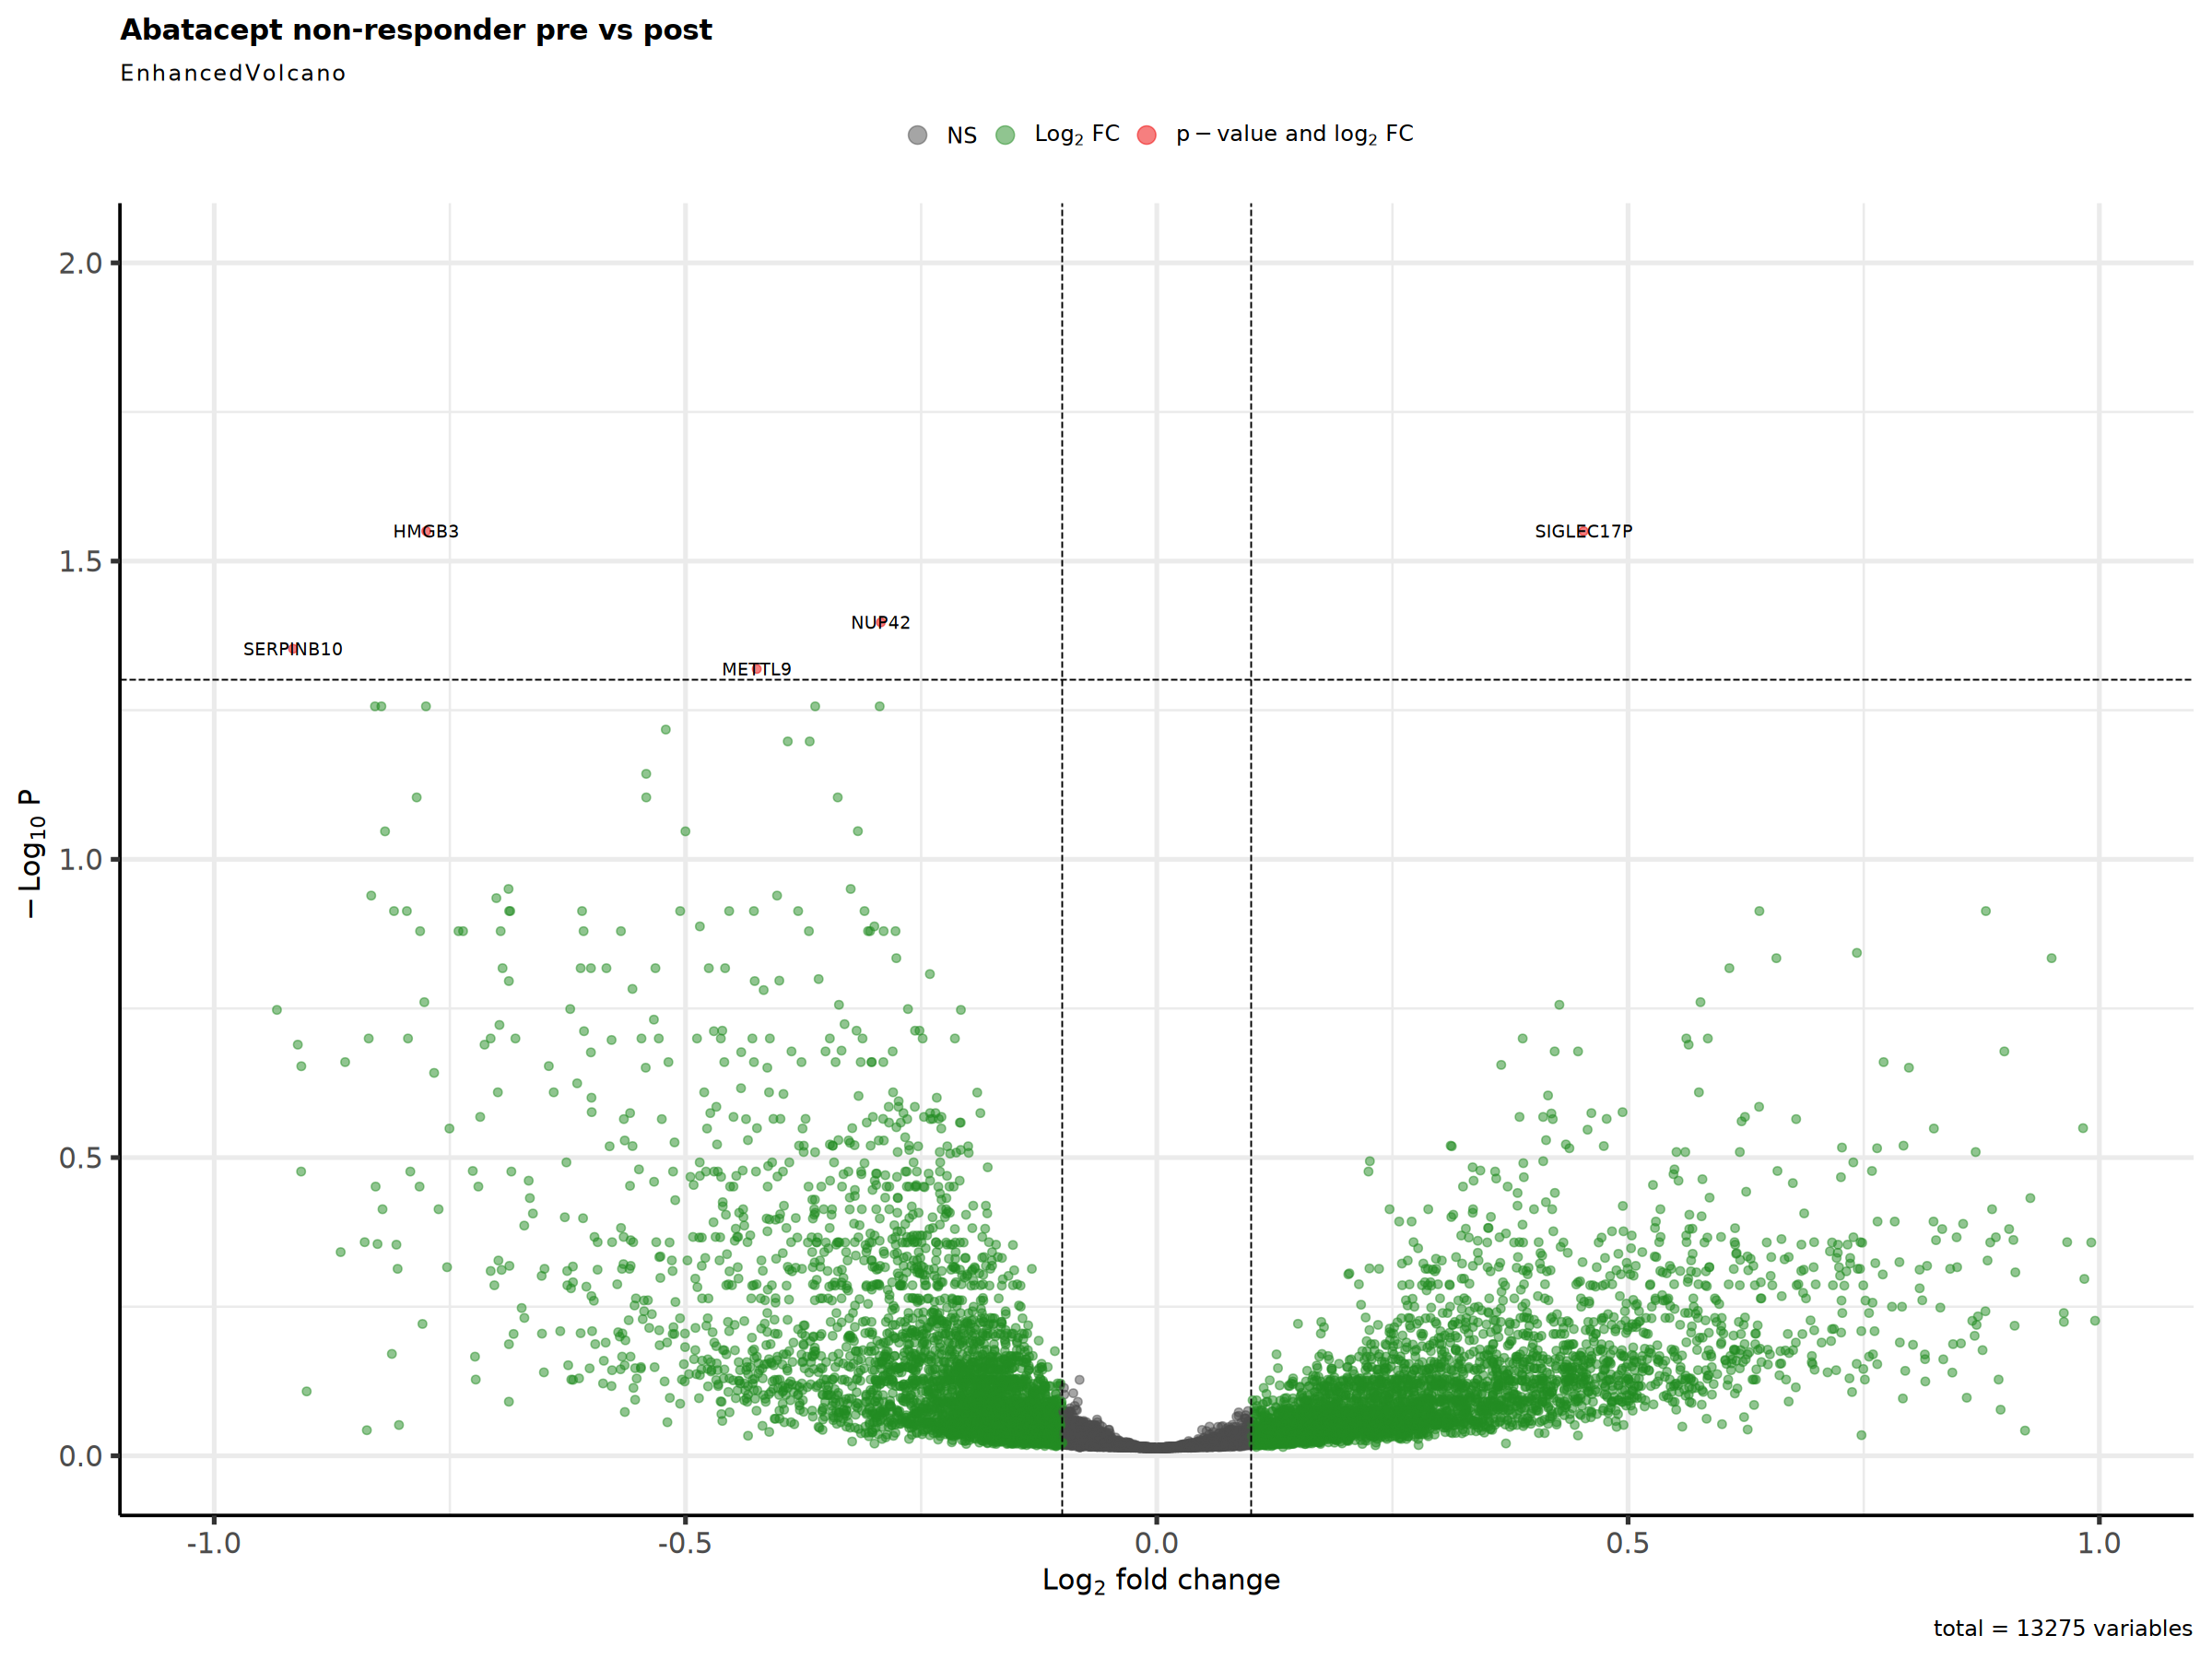

In [ ]:
# Plot the DA results for aim1
p1 <- EnhancedVolcano::EnhancedVolcano(dds_nonresp_res_tb,
    title = "Abatacept non-responder pre vs post",
    lab = dds_nonresp_res_tb$gene,
    x = "log2FoldChange",
    y = "q_values",
    pCutoff = 0.05,
    FCcutoff = 0.1,
    pointSize = 2.0, # drawConnectors = TRUE,
    widthConnectors = 1.0,
    colConnectors = "black",
    arrowheads = FALSE,
    labSize = 4.0
) +
    xlim(c(-1, 1)) + ylim(0, 2)
p1
ggsave(file.path(fig_path, paste0(proj_name, "Abatacept_nonresponders_prevspost_valcano_plot.png")),
    width = 8, height = 6
)


### run a HyperGeometric Enrichment test


In [ ]:
library(hypeR)


In [ ]:
# # use abt response genes as the reference
# # check if the aim3 degs are significant enriched.
# celltype_test = 'Core_naive_CD4_T_cell'
# aim3_sig_genes <- aim3_degs %>%
#     filter(cell_type==celltype_test&q_values<0.1)%>%pull(gene)
# aim3_bg_genes <- aim3_degs %>%
#     filter(cell_type==celltype_test)%>%pull(gene)

# abt_sig_genes <- dds_nonresp_res_tb%>%filter(q_values<0.1)%>%pull(gene)


# hyp_obj <- hypeR(aim3_sig_genes, abt_genes_list,
#                  test="hypergeometric", background=length(aim3_bg_genes), plotting=TRUE)
# hyp_obj


In [ ]:
# make a degs list per cell type
celltypes_test <- aim3_degs %>%
    filter(q_values < 0.1) %>%
    group_by(cell_type) %>%
    tally() %>%
    filter(n > 10) %>%
    pull(cell_type) %>%
    unique()
aim3_genes_list <- lapply(celltypes_test, function(x) {
    sig_genes <- aim3_degs %>%
        filter(cell_type == x & q_values < 0.1) %>%
        pull(gene)
    return(sig_genes)
})
names(aim3_genes_list) <- celltypes_test
celltypes_test


[1] "CM CD4 T cell"                    "CM CD8 T cell"                   
[3] "Core naive B cell"                "Core naive CD4 T cell"           
[5] "Core naive CD8 T cell"            "GZMK+ CD27+ EM CD8 T cell"       
[7] "KLRF1+ GZMB+ CD27- EM CD8 T cell" "KLRF1- GZMB+ CD27- EM CD8 T cell"
[9] "Naive CD4 Treg"

In [ ]:
# aim3_genes_list
abtnon_sig_genes <- dds_nonresp_res_tb %>%
    filter(q_values < 0.1) %>%
    pull(gene)
abtnon_bg_genes <- dds_nonresp_res_tb %>% pull(gene)

hyp_nonp <- hypeR(abtnon_sig_genes, aim3_genes_list,
    test = "hypergeometric", background = length(abtnon_bg_genes), plotting = TRUE
)


In [ ]:
hyp_to_excel(hyp_nonp, file_path = file.path(output_path, "non_responders_pathways.xlsx"))


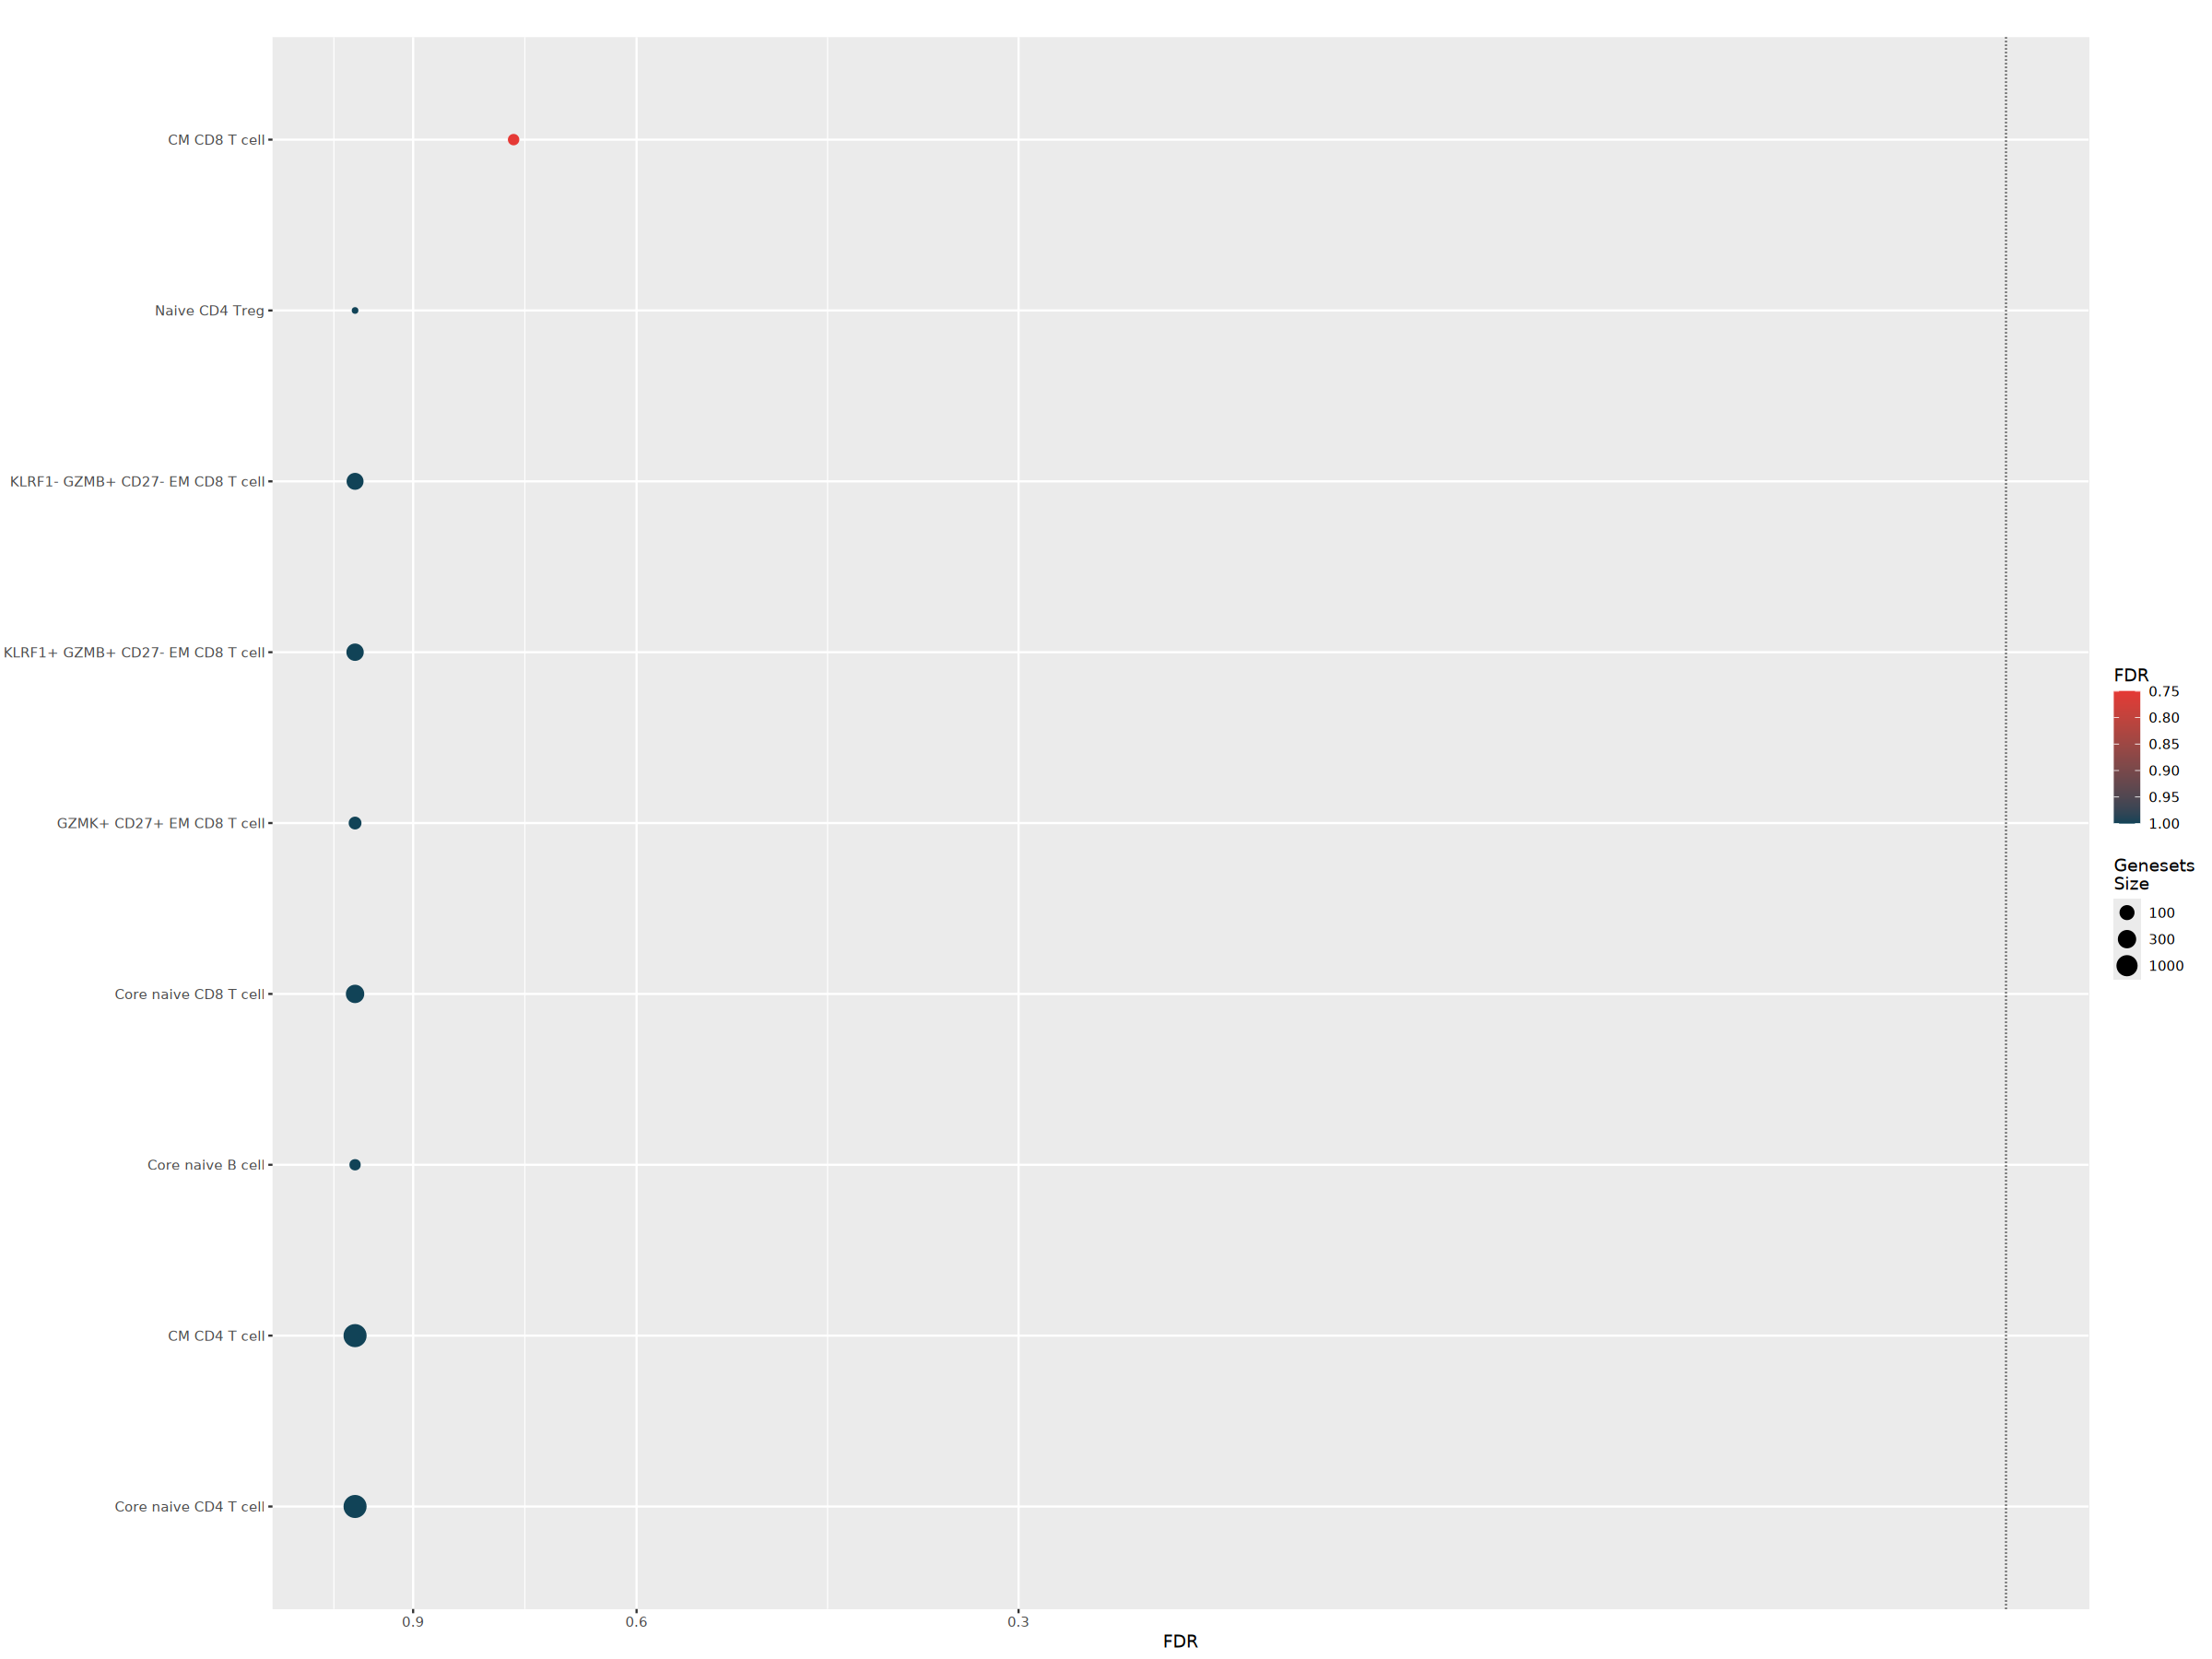

In [ ]:
hyp_dots(hyp_nonp)
ggsave(file.path(fig_path, paste0(proj_name, "gene_signature_abt_nonresponder.png")), width = 8, height = 4)


In [ ]:
# combine the deg results
abtnon_aim3_degs_comparison <- dds_nonresp_res_tb %>%
      full_join(aim3_degs,
            by = c("gene"),
            suffix = c("_abt", "_aim3")
      ) %>%
      dplyr::rename("pvalue_aim3" = "p.value") %>%
      filter(q_values_aim3 < 0.1 & q_values_abt < 0.1 &
            !is.na(log2FoldChange)) %>%
      mutate(sig = case_when(
            q_values_abt <= 0.05 & q_values_aim3 <= 0.1 ~ "AbtSig&Aim3Sig",
            q_values_abt > 0.05 & q_values_aim3 <= 0.1 ~ "Aim3Sig",
            q_values_abt <= 0.05 & q_values_aim3 > 0.1 ~ "AbtSig",
            q_values_abt > 0.05 & q_values_aim3 > 0.1 ~ "No sig"
      )) %>%
      mutate(
            aim3_direction = if_else(estimate > 0, "aim3_up", "aim3_down"),
            abt_direction = if_else(log2FoldChange > 0, "abt_up", "abt_down")
      )
abtnon_aim3_degs_comparison %>% colnames()


[1] "gene"           "baseMean"       "log2FoldChange" "lfcSE"         
 [5] "stat"           "pvalue"         "q_values_abt"   "cell_type"     
 [9] "effect"         "group"          "term"           "estimate"      
[13] "std.error"      "statistic"      "df"             "pvalue_aim3"   
[17] "q_values_aim3"  "sig"            "aim3_direction" "abt_direction"

In [ ]:
abtnon_aim3_degs_comparison %>% filter(is.na(sig))


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values_abt,cell_type,effect,group,term,estimate,std.error,statistic,df,pvalue_aim3,q_values_aim3,sig,aim3_direction,abt_direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>


In [ ]:
# calculate the numbers
abtnon_aim3_degs_comparison_counts <- abtnon_aim3_degs_comparison %>%
    group_by(cell_type, aim3_direction, abt_direction) %>%
    tally() %>%
    ungroup()
abtnon_aim3_degs_comparison_counts


cell_type,aim3_direction,abt_direction,n
<chr>,<chr>,<chr>,<int>
CM CD4 T cell,aim3_down,abt_down,5
CM CD8 T cell,aim3_down,abt_down,1
Core naive CD4 T cell,aim3_down,abt_down,5


In [ ]:
abtnon_aim3_degs_comparison_counts %>%
    filter(cell_type %in% c("CM CD4 T cell")) %>%
    pivot_wider(
        id_cols = c(cell_type, aim3_direction),
        names_from = abt_direction, values_from = n
    )


cell_type,aim3_direction,abt_down
<chr>,<chr>,<int>
CM CD4 T cell,aim3_down,5


In [ ]:
abtnon_aim3_degs_comparison_counts %>% head()


cell_type,aim3_direction,abt_direction,n
<chr>,<chr>,<chr>,<int>
CM CD4 T cell,aim3_down,abt_down,5
CM CD8 T cell,aim3_down,abt_down,1
Core naive CD4 T cell,aim3_down,abt_down,5


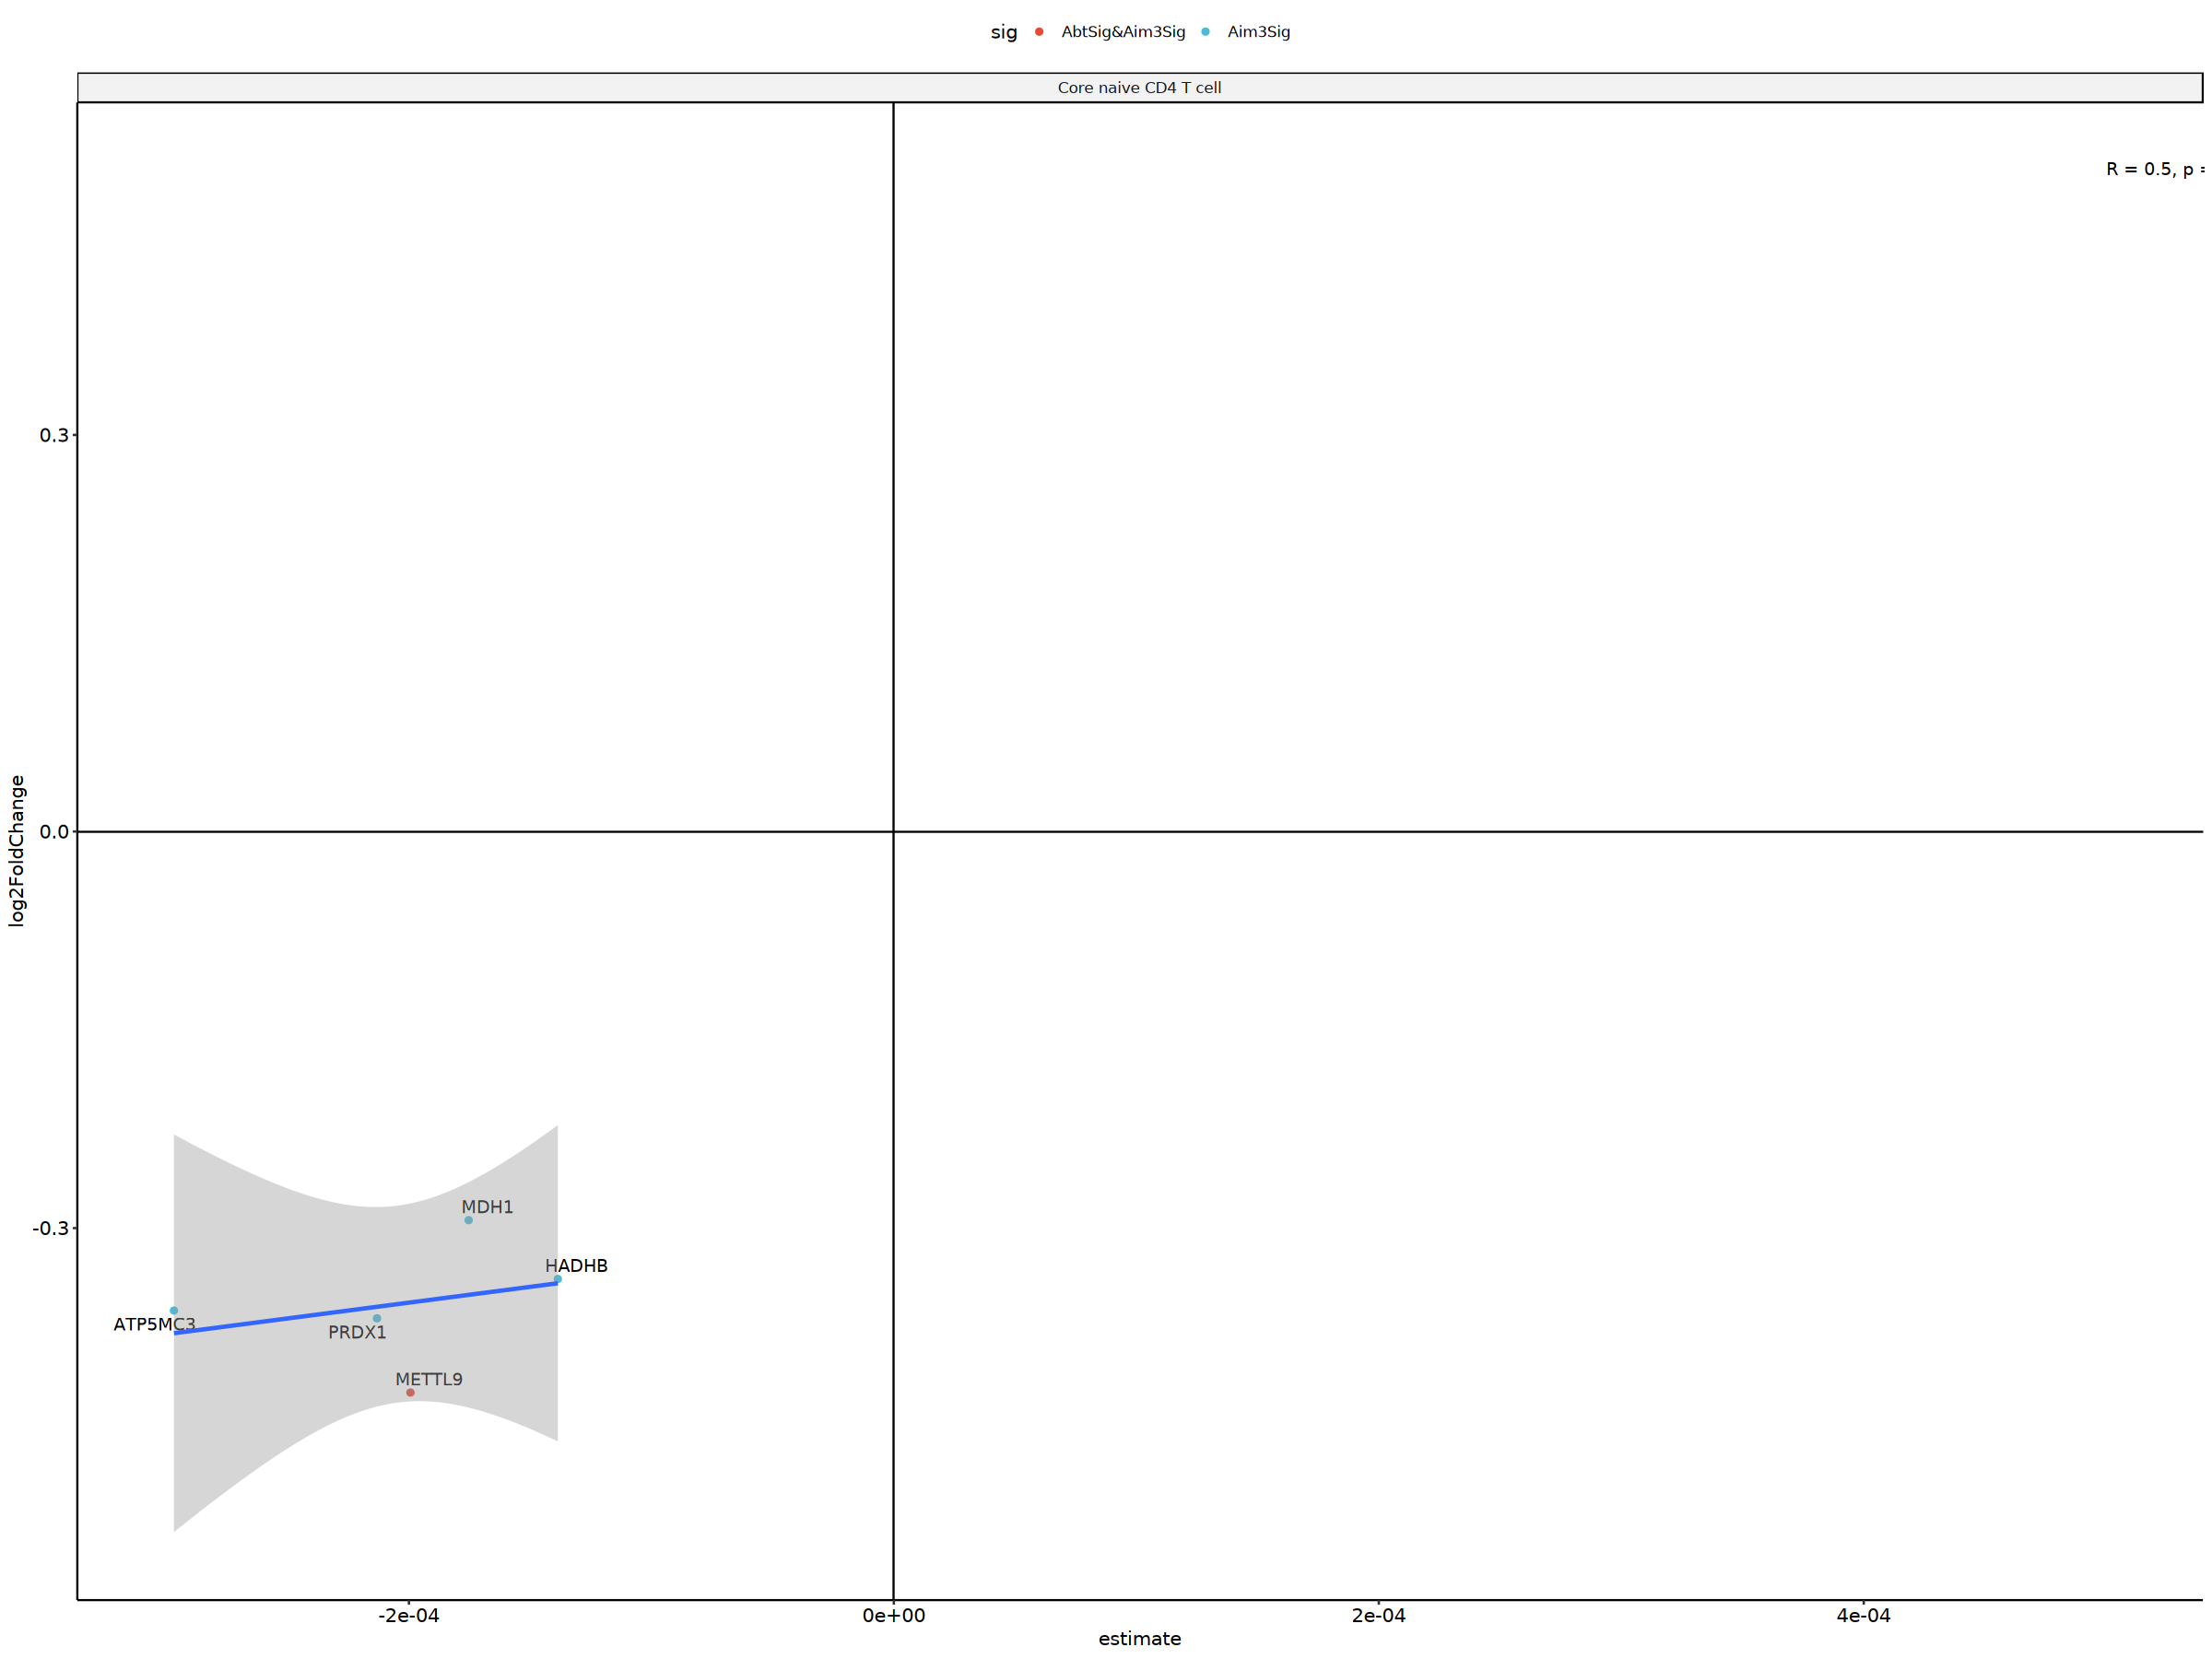

In [ ]:
# plot the significant genes
abtnon_aim3_degs_comparison %>%
    filter(cell_type %in% c("Core naive CD4 T cell")) %>%
    ggplot(aes(y = log2FoldChange, x = estimate)) +
    geom_point(aes(color = sig)) +
    ggrepel::geom_text_repel(aes(label = gene), ) +
    stat_smooth(
        method = "lm",
        formula = y ~ x,
        geom = "smooth"
    ) +
    geom_vline(xintercept = 0) +
    geom_hline(yintercept = 0) +
    ggpubr::stat_cor(method = "spearman", label.x = 0.0005, label.y = 0.5) +
    facet_wrap(vars(cell_type)) +
    scale_color_manual(values = npg_color) +
    theme_pubr()
ggsave(file.path(fig_path, paste0(proj_name, "abecetpt_nonresponder_Aim3_deg_cd4nat_logfc_cor_plot.png")),
    width = 6, height = 6
)


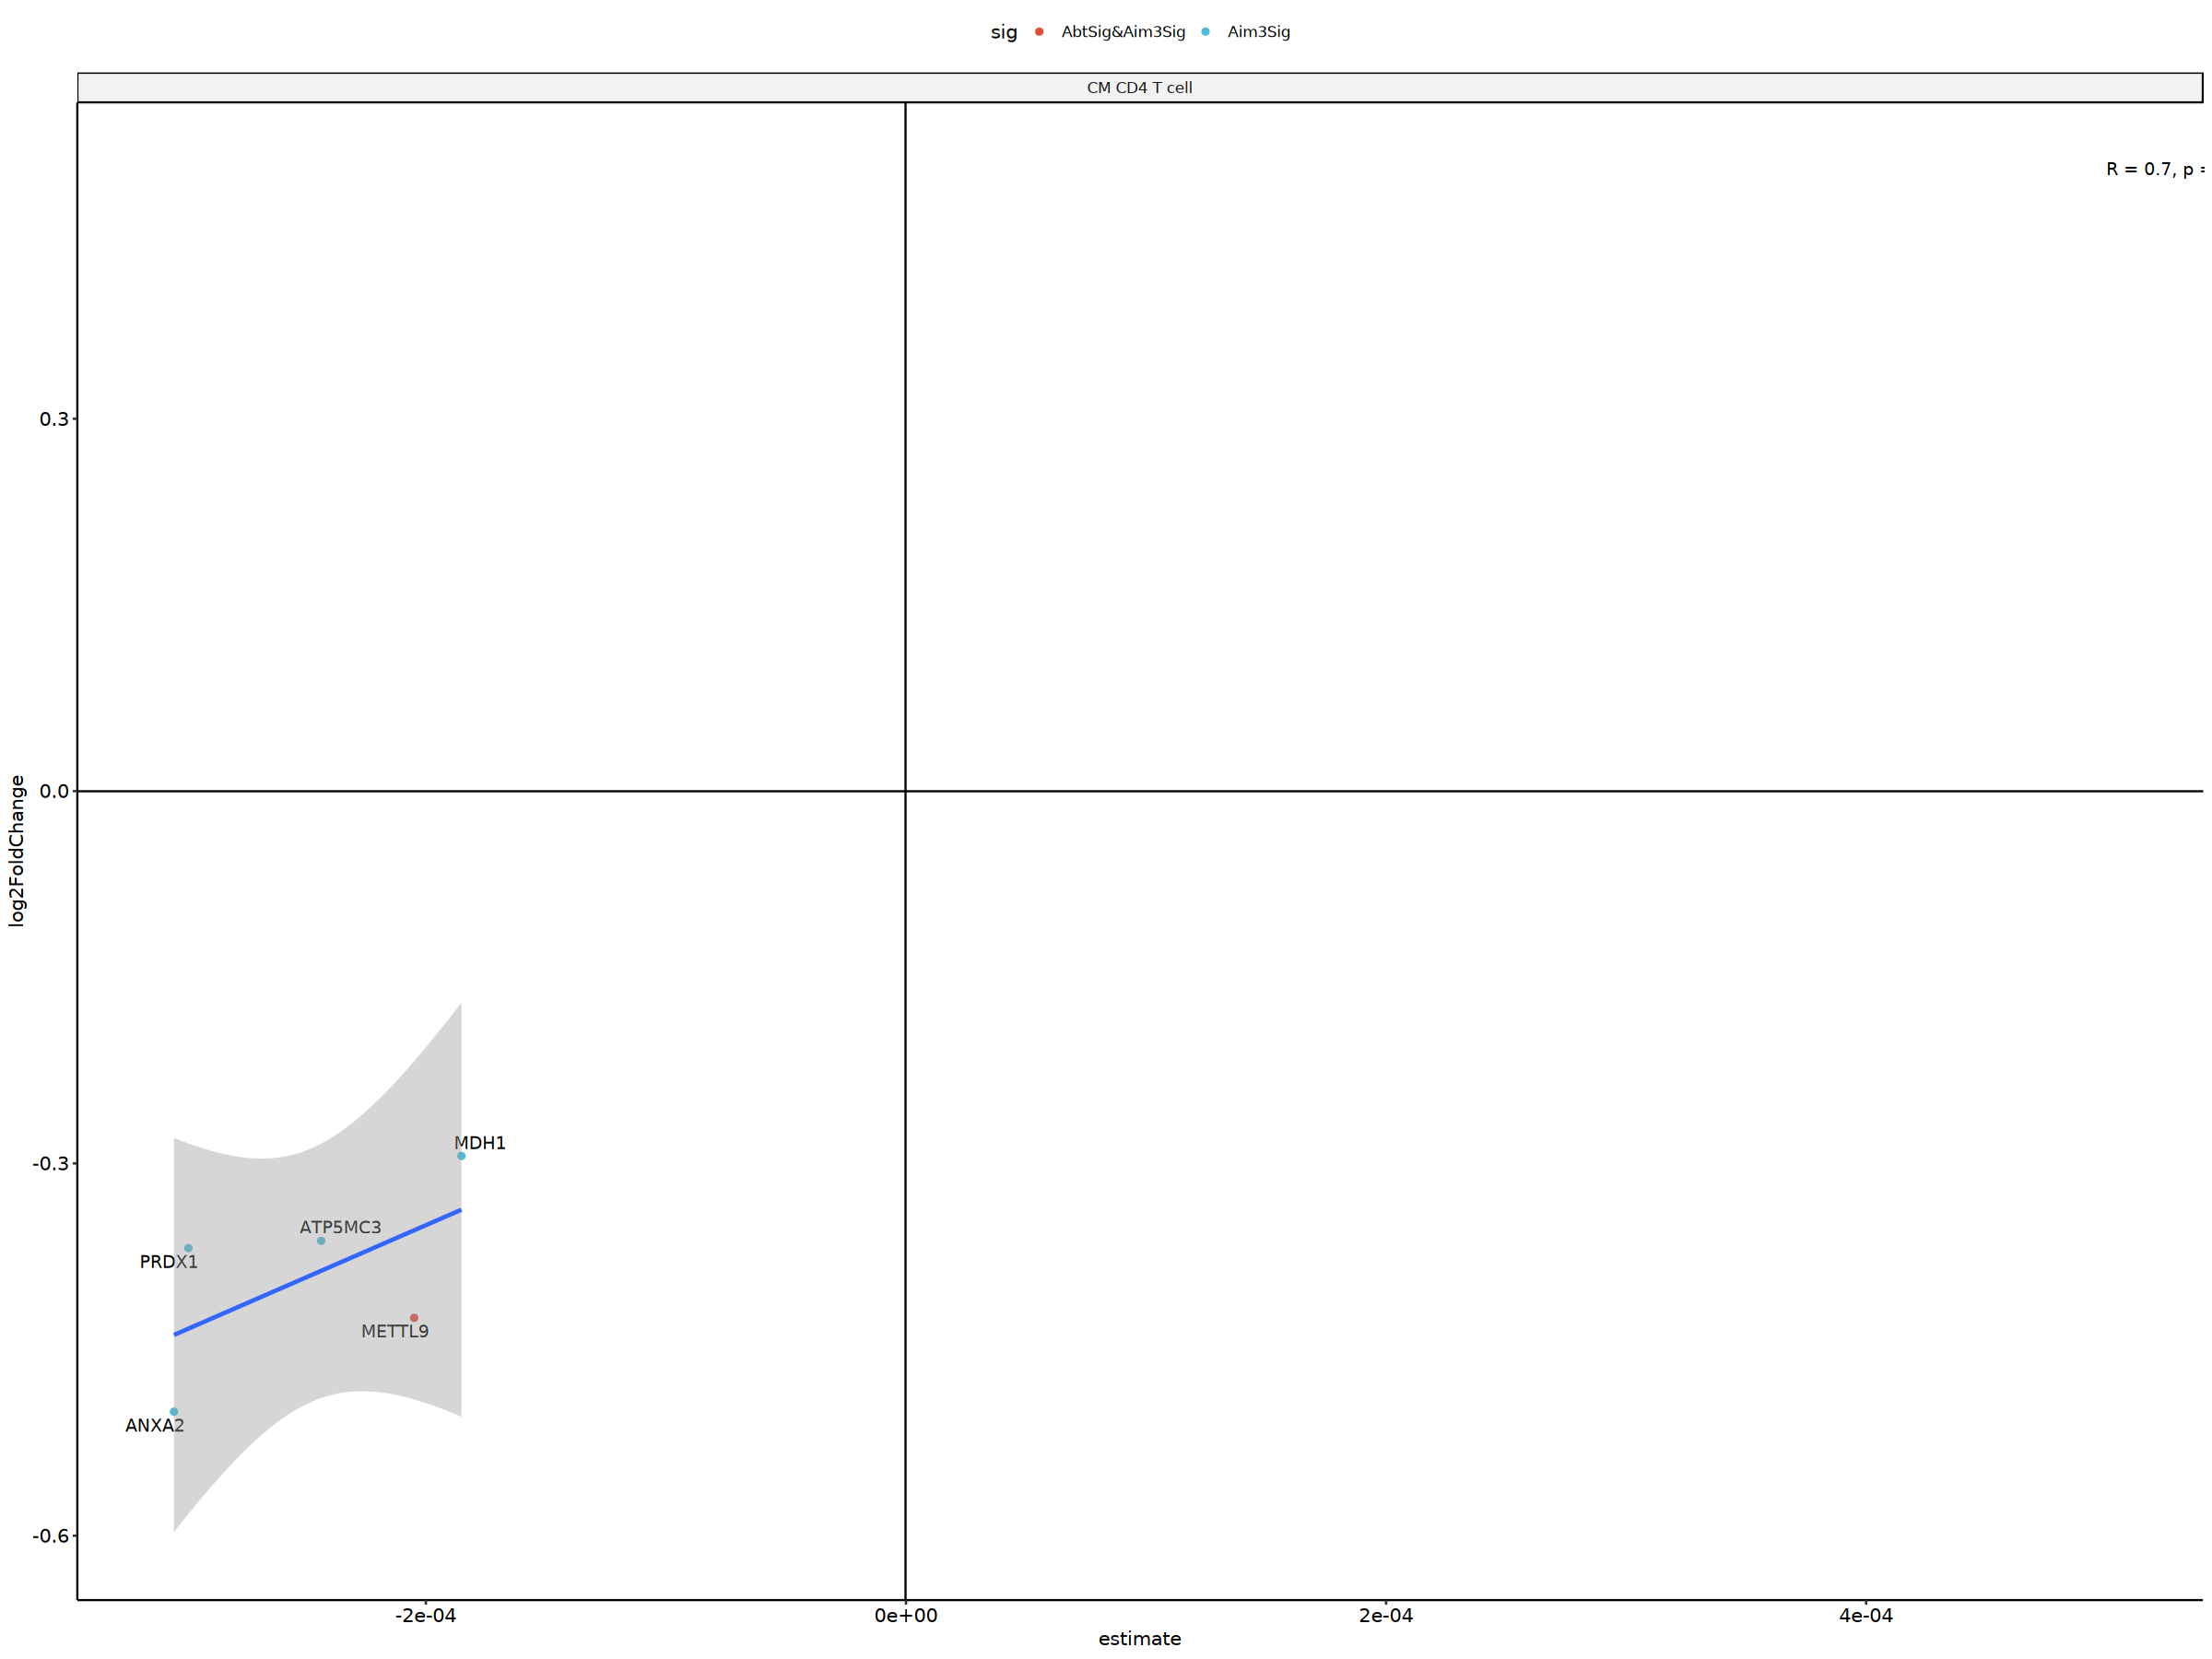

In [ ]:
# plot the significant genes
abtnon_aim3_degs_comparison %>%
    filter(cell_type %in% c("CM CD4 T cell")) %>%
    ggplot(aes(y = log2FoldChange, x = estimate)) +
    geom_point(aes(color = sig)) +
    ggrepel::geom_text_repel(aes(label = gene), ) +
    stat_smooth(
        method = "lm",
        formula = y ~ x,
        geom = "smooth"
    ) +
    geom_vline(xintercept = 0) +
    geom_hline(yintercept = 0) +
    ggpubr::stat_cor(method = "spearman", label.x = 0.0005, label.y = 0.5) +
    facet_wrap(vars(cell_type)) +
    scale_color_manual(values = npg_color) +
    theme_pubr()
ggsave(file.path(fig_path, paste0(proj_name, "abecetpt_nonresponder_Aim3_deg_cd4CM_logfc_cor_plot.png")),
    width = 6, height = 6
)


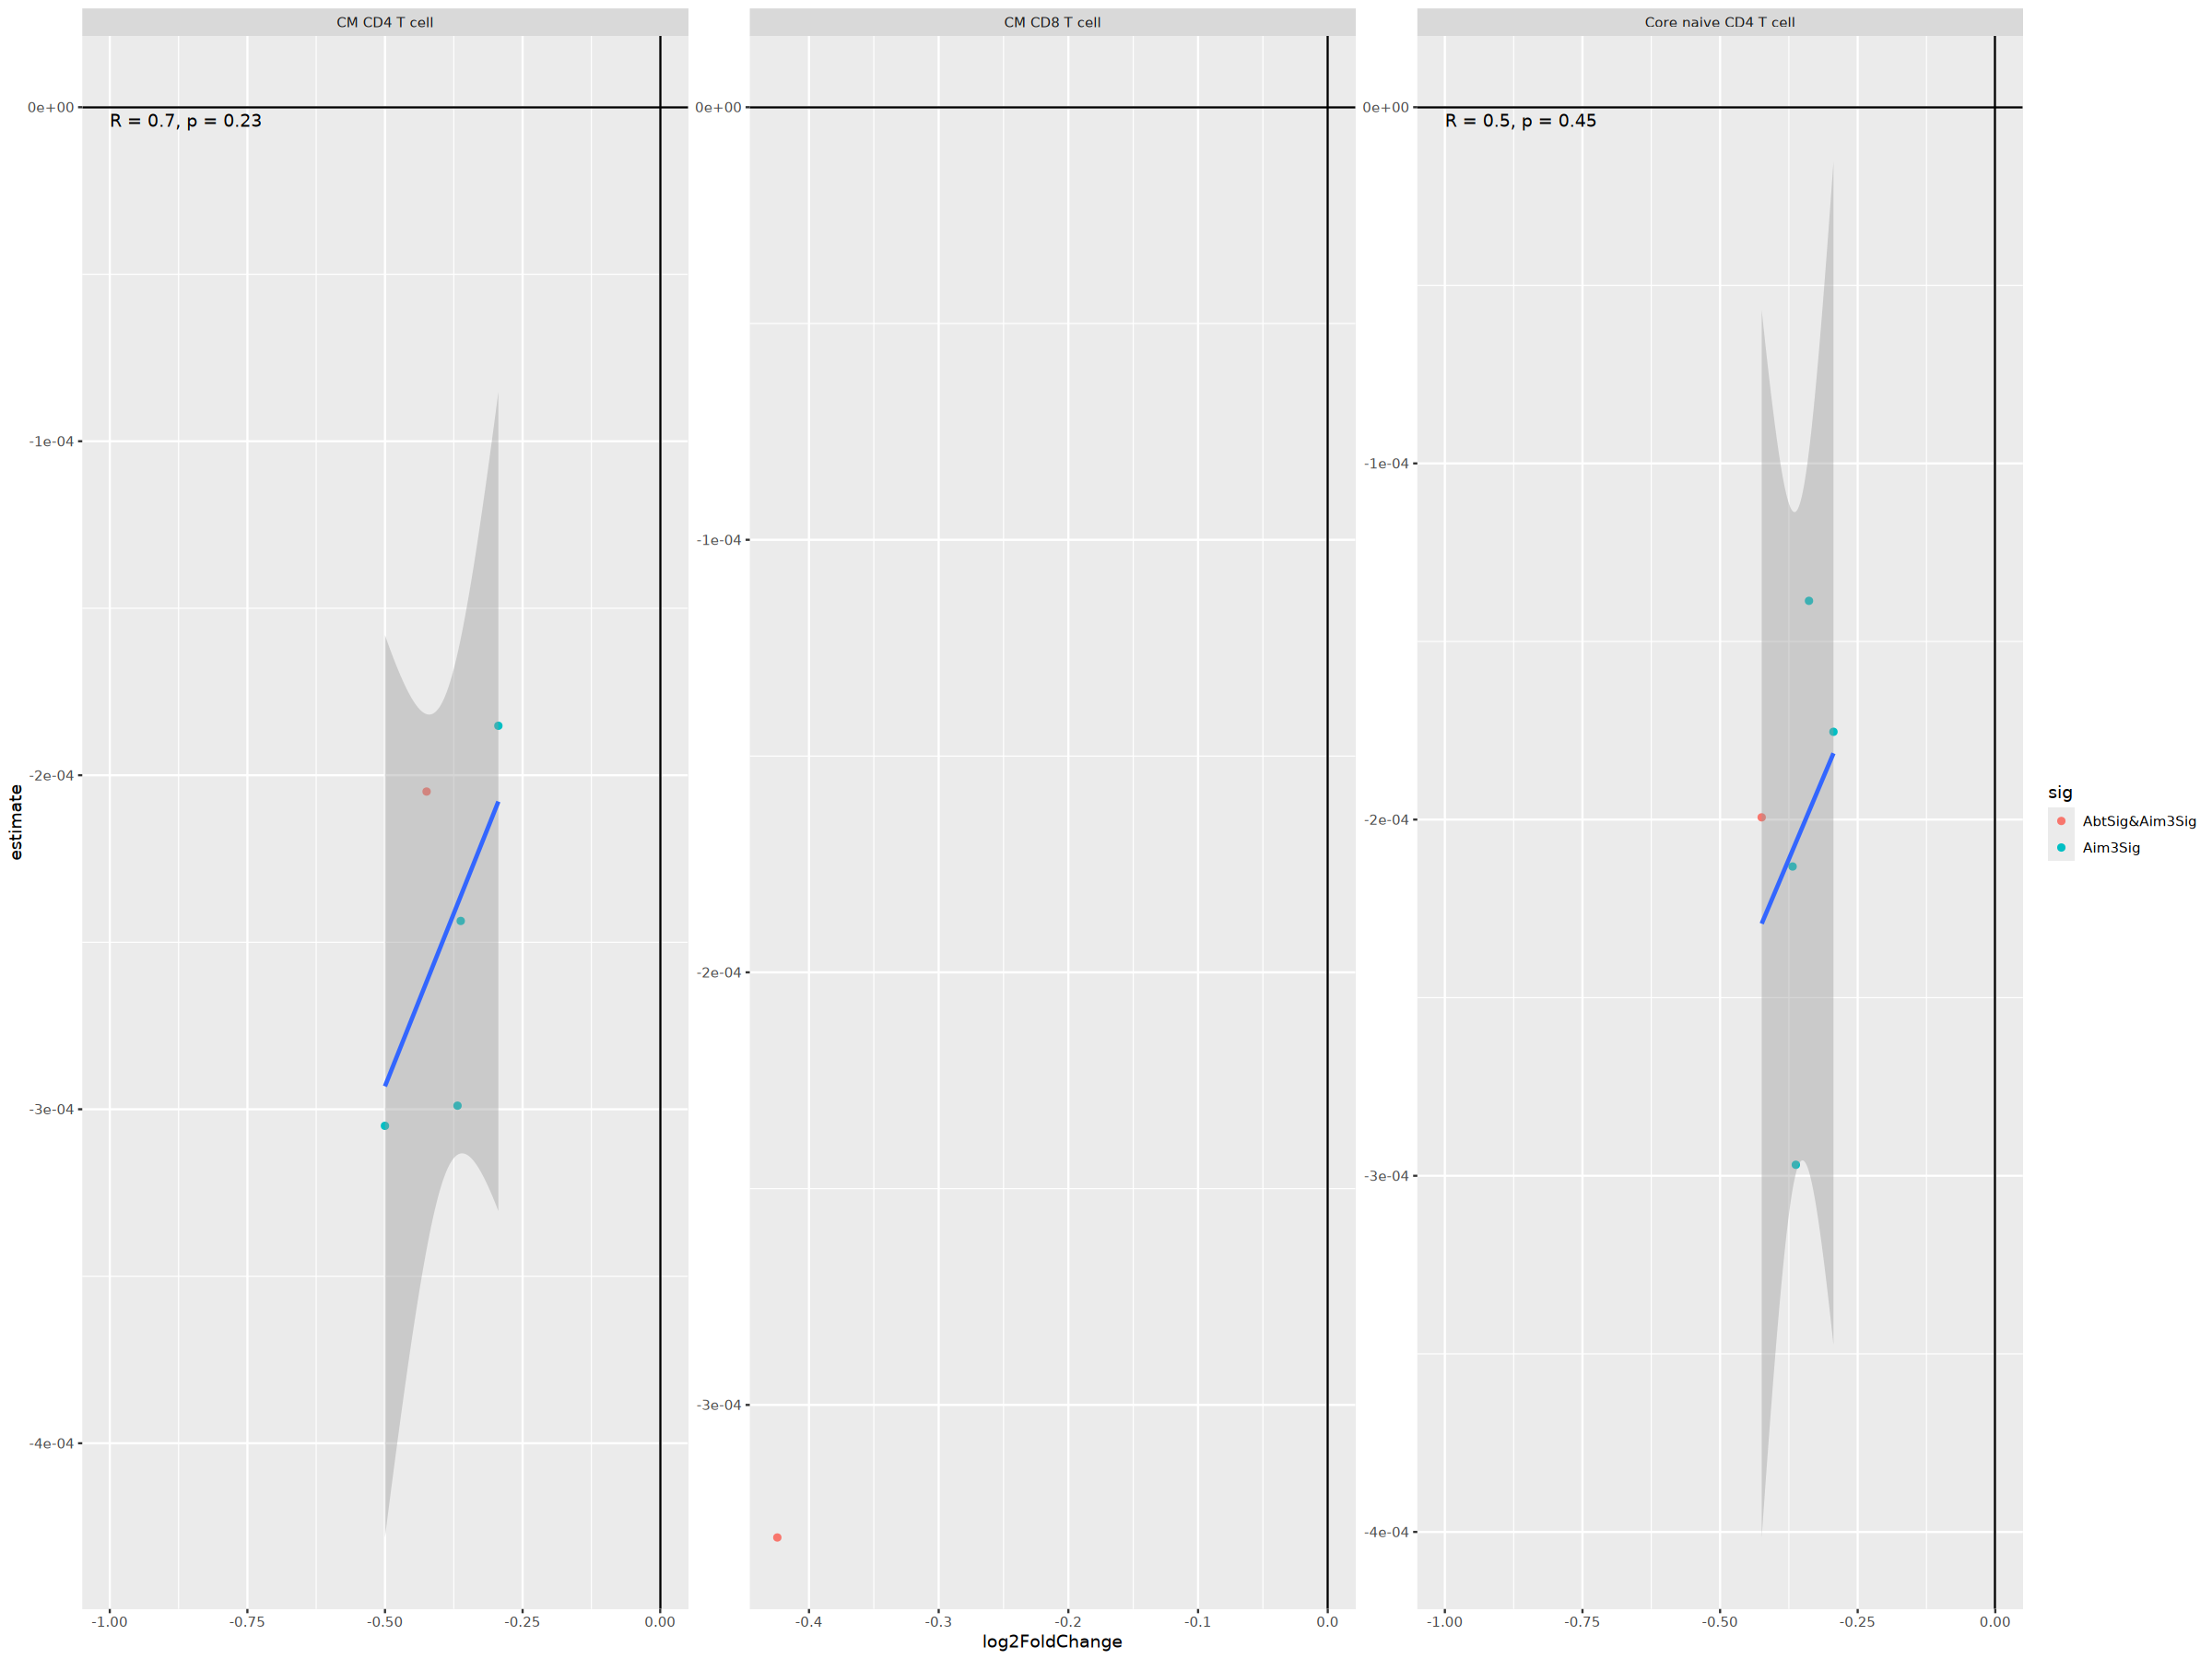

In [ ]:
# plot aim1 and aim3 corrlation
p1 <- abtnon_aim3_degs_comparison %>%
  ggplot(aes(x = log2FoldChange, y = estimate)) +
  geom_point(aes(color = sig)) +
  stat_smooth(
    method = "lm",
    formula = y ~ x,
    geom = "smooth"
  ) +
  geom_vline(xintercept = 0) +
  geom_hline(yintercept = 0) +
  facet_wrap(vars(cell_type), scale = "free") +
  ggpubr::stat_cor(method = "spearman", label.x = -1)
p1
ggsave(file.path(fig_path, paste0("abecetpt_non_responder_Aim3_deg_logfc_cor_plot.png")),
  width = 18, height = 12
)


# plot the gene set enrichment results for responders and non-responders


In [ ]:
# combine the HyperGeometric test result
resp_data <- hyp_obj$data %>%
    as_tibble(rownames = "cell_type") %>%
    mutate(response = "Responder")
nonp_data <- hyp_nonp$data %>%
    as_tibble(rownames = "cell_type") %>%
    mutate(response = "Non-responder")
hyp_results <- resp_data %>%
    bind_rows(nonp_data) %>%
    mutate(
        cell_type = factor(cell_type, levels = rev(unique(cell_type))),
        "log10_FDR" = -log10(fdr),
        cell_type_anno = recode(cell_type,
            "Core naive CD4 T cell" = "Naive CD4 T",
            "CM CD4 T cell" = "CM CD4 T",
            "Core naive CD8 T cell" = "Naive CD8 T",
            "KLRF1+ GZMB+ CD27- EM CD8 T cell" = "KLRF1+ CD8 EM",
            "Core naive B cell" = "Core naive B",
            "KLRF1- GZMB+ CD27- EM CD8 T cell" = "KLRF1- CD8 EM",
            "GZMK+ CD27+ EM CD8 T cell" = "GZMK+ CD8 EM"
        )
    )
hyp_results %>% select(-hits)


cell_type,label,pval,fdr,signature,geneset,overlap,background,response,log10_FDR,cell_type_anno
<fct>,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<fct>
Core naive CD4 T cell,Core naive CD4 T cell,3.3e-05,0.0003,965,2651,237,13608,Responder,3.522878745,Naive CD4 T
CM CD4 T cell,CM CD4 T cell,5.0e-04,0.0022,965,2712,233,13608,Responder,2.657577319,CM CD4 T
Core naive CD8 T cell,Core naive CD8 T cell,2.5e-01,0.7400,965,305,25,13608,Responder,0.130768280,Naive CD8 T
Naive CD4 Treg,Naive CD4 Treg,4.0e-01,0.7400,965,32,3,13608,Responder,0.130768280,Naive CD4 Treg
KLRF1+ GZMB+ CD27- EM CD8 T cell,KLRF1+ GZMB+ CD27- EM CD8 T cell,4.1e-01,0.7400,965,209,16,13608,Responder,0.130768280,KLRF1+ CD8 EM
Core naive B cell,Core naive B cell,6.3e-01,0.9400,965,45,3,13608,Responder,0.026872146,Core naive B
KLRF1- GZMB+ CD27- EM CD8 T cell,KLRF1- GZMB+ CD27- EM CD8 T cell,7.4e-01,0.9600,965,181,11,13608,Responder,0.017728767,KLRF1- CD8 EM
CM CD8 T cell,CM CD8 T cell,9.7e-01,0.9900,965,46,1,13608,Responder,0.004364805,CM CD8 T cell
GZMK+ CD27+ EM CD8 T cell,GZMK+ CD27+ EM CD8 T cell,9.9e-01,0.9900,965,59,1,13608,Responder,0.004364805,GZMK+ CD8 EM


## plot Fig 7B

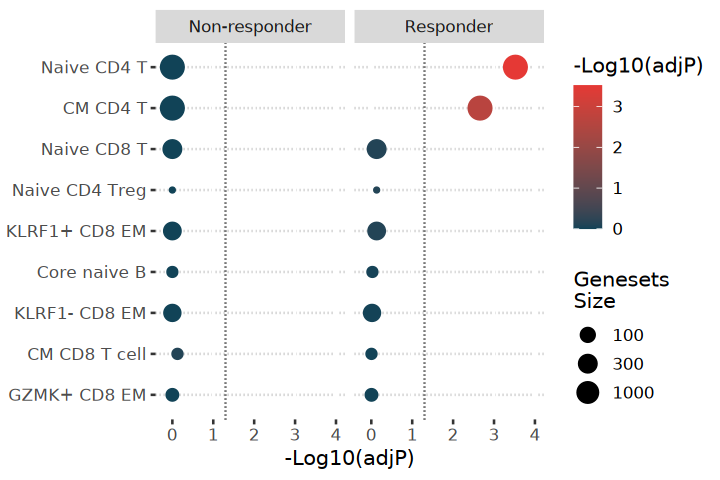

In [ ]:
# plot the pathway enrichment results
options(repr.plot.width = 6, repr.plot.height = 4)
p1 <- ggplot(hyp_results, aes(
      x = log10_FDR, size = geneset,
      y = cell_type_anno,
      color = log10_FDR
)) +
      geom_point() +
      facet_wrap(vars(response)) +
      scale_color_continuous(low = "#114357", high = "#E53935") +
      geom_vline(xintercept = -log10(0.05), linetype = "dotted") +
      ggpubr::theme_pubclean() +
      xlim(c(-0.2, 4)) +
      theme(
            axis.text.y = element_text(size = 10),
            axis.title.y = element_blank(), legend.position = "right"
      ) +
      scale_size_continuous(trans = scales::log10_trans()) +
      labs(size = "Genesets\nSize", x = "-Log10(adjP)", color = "-Log10(adjP)")
p1
ggsave(file.path(fig_path, paste0("Fig6_abt_geneset_enrichment.pdf")),
      width = 6, height = 4
)


In [ ]:
abt_aim3_degs_comparison %>% colnames()


[1] "gene"           "baseMean"       "log2FoldChange" "lfcSE"         
 [5] "stat"           "pvalue"         "q_values_abt"   "cell_type"     
 [9] "effect"         "group"          "term"           "estimate"      
[13] "std.error"      "statistic"      "df"             "pvalue_aim3"   
[17] "q_values_aim3"  "sig"            "aim3_direction" "abt_direction"

In [ ]:
# filter the significant gene only genes
abt_aim3_degs_comparison_sig <- abt_aim3_degs_comparison %>%
    filter(q_values_abt < 0.1 & q_values_aim3 < 0.1) %>%
    mutate(
        direction =
            case_when(
                aim3_direction == "aim3_up" & abt_direction == "abt_up" ~
                    "Increased during progression to RA&\nIncreased post ABT",
                aim3_direction == "aim3_down" & abt_direction == "abt_down" ~
                    "Decreased during progression to RA&\nDecreased post ABT",
                aim3_direction == "aim3_down" & abt_direction == "abt_up" ~
                    "Decreased during progression to RA&\nIncreased post ABT",
                aim3_direction == "aim3_up" & abt_direction == "abt_down" ~
                    "Increased during progression to RA&\nDecreased post ABT"
            )
    )
abt_aim3_degs_comparison_sig %>% head()


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values_abt,cell_type,effect,group,⋯,estimate,std.error,statistic,df,pvalue_aim3,q_values_aim3,sig,aim3_direction,abt_direction,direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
CD99,3134.7115,0.4866086,0.1771889,2.746271,0.0060277009,0.075772893,CM CD4 T cell,fixed,NA,⋯,-0.0002296694,0.0001173063,-1.957861,40.31672,0.05719209,0.06575596,AbtSig&Aim3Sig,aim3_down,abt_up,Decreased during progression to RA& Increased post ABT
CD99,3134.7115,0.4866086,0.1771889,2.746271,0.0060277009,0.075772893,Core naive CD4 T cell,fixed,NA,⋯,-0.0001990364,0.0001113067,-1.788180,37.32523,0.08186729,0.07004380,AbtSig&Aim3Sig,aim3_down,abt_up,Decreased during progression to RA& Increased post ABT
MAD1L1,153.0922,0.8508763,0.2211721,3.847123,0.0001195129,0.005544172,CM CD4 T cell,fixed,NA,⋯,-0.0002560724,0.0001346330,-1.902003,40.22560,0.06434849,0.06847406,AbtSig&Aim3Sig,aim3_down,abt_up,Decreased during progression to RA& Increased post ABT
MAD1L1,153.0922,0.8508763,0.2211721,3.847123,0.0001195129,0.005544172,Core naive CD4 T cell,fixed,NA,⋯,-0.0004198534,0.0001582490,-2.653118,40.29612,0.01135635,0.03820139,AbtSig&Aim3Sig,aim3_down,abt_up,Decreased during progression to RA& Increased post ABT
RBM6,1467.7965,-0.7217532,0.2460898,-2.932886,0.0033582771,0.054751190,CM CD4 T cell,fixed,NA,⋯,0.0002232038,0.0001010066,2.209794,44.88062,0.03226333,0.05520082,AbtSig&Aim3Sig,aim3_up,abt_down,Increased during progression to RA& Decreased post ABT
RBM6,1467.7965,-0.7217532,0.2460898,-2.932886,0.0033582771,0.054751190,Core naive CD4 T cell,fixed,NA,⋯,0.0002205007,0.0001036961,2.126412,43.99683,0.03911578,0.05151709,AbtSig&Aim3Sig,aim3_up,abt_down,Increased during progression to RA& Decreased post ABT


In [ ]:
proj_name


[1] "ALTRA_AIM3_scRNA_validation_"

In [ ]:
abt_aim3_degs_comparison_sig %>% write_csv(file.path(output_path, paste0(proj_name, "ABT_responder_AIM3_degs.csv")))


In [ ]:
abt_aim3_degs_comparison_sig <- read_csv(file.path(output_path, paste0(proj_name, "ABT_responder_AIM3_degs.csv"))) %>%
    mutate(direction = factor(direction))


Rows: 532 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): gene, cell_type, effect, term, sig, aim3_direction, abt_direction,...
dbl (12): baseMean, log2FoldChange, lfcSE, stat, pvalue, q_values_abt, estim...
lgl  (1): group

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
abt_aim3_degs_comparison_sig$direction %>% levels()
abt_colors <- c("grey80", "#F59F00", "#840032", "grey80")


[1] "Decreased during progression to RA&\nDecreased post ABT"
[2] "Decreased during progression to RA&\nIncreased post ABT"
[3] "Increased during progression to RA&\nDecreased post ABT"
[4] "Increased during progression to RA&\nIncreased post ABT"

direction,n
<fct>,<int>
Decreased during progression to RA& Decreased post ABT,11
Decreased during progression to RA& Increased post ABT,164
Increased during progression to RA& Decreased post ABT,40
Increased during progression to RA& Increased post ABT,22


Warning message:
“Removed 229 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 229 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


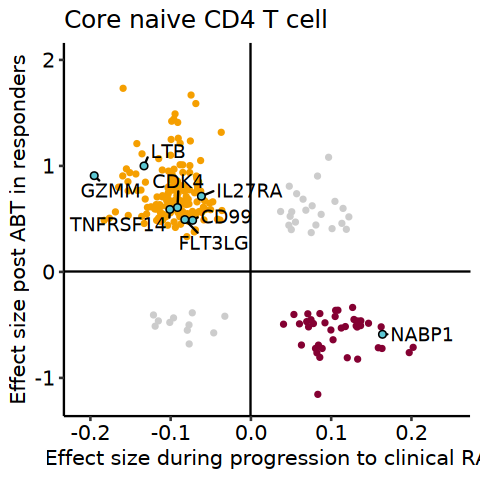

In [ ]:
# plot the significant genes
options(repr.plot.width = 4, repr.plot.height = 4)
cell_type_plot <- "Core naive CD4 T cell"
# label perticular genes
hightlight_genes <- c(
    "CD99", "CDK4", "CXCR3",
    "FLT3LG", "GZMM", "LTB", "TNFRSF14",
    "IL27RA", "NABP1"
)
abt_aim3_degs_comparison_sig %>%
    filter(cell_type == cell_type_plot) %>%
    group_by(direction) %>%
    tally()
p1 <- abt_aim3_degs_comparison_sig %>%
    filter(cell_type == cell_type_plot) %>%
    mutate(highlight_gene = if_else(gene %in% hightlight_genes, gene, NA)) %>%
    ggplot(aes(y = log2FoldChange, x = 365 * estimate)) +
    geom_point(aes(color = direction), size = 1) +
    ggrepel::geom_text_repel(aes(label = highlight_gene), min.segment.length = 0, nudge_x = 0.015) +
    geom_point(
        data = abt_aim3_degs_comparison_sig %>% filter(cell_type == cell_type_plot & gene %in% hightlight_genes),
        fill = "#5DC7D3", color = "black", size = 1.5, shape = 21, stroke = .5
    ) + # Yellow fill with black outline
    geom_vline(xintercept = 0) +
    geom_hline(yintercept = 0) +
    ylim(-1.2, 2) +
    xlim(-0.21, 0.25) +
    scale_color_manual(values = abt_colors) +
    theme_pubr() +
    guides(color = "none") +
    labs(
        title = cell_type_plot, x = "Effect size during progression to clinical RA",
        y = "Effect size post ABT in responders"
    )
p1
ggsave(file.path(fig_path, paste0(proj_name, "abecetpt_responder_Aim3_deg_", cell_type_plot, "_logfc_cor_plot_labeled.pdf")),
    width = 4, height = 4
)


direction,n
<fct>,<int>
Decreased during progression to RA& Decreased post ABT,8
Decreased during progression to RA& Increased post ABT,165
Increased during progression to RA& Decreased post ABT,37
Increased during progression to RA& Increased post ABT,23


Warning message:
“Removed 225 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 225 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


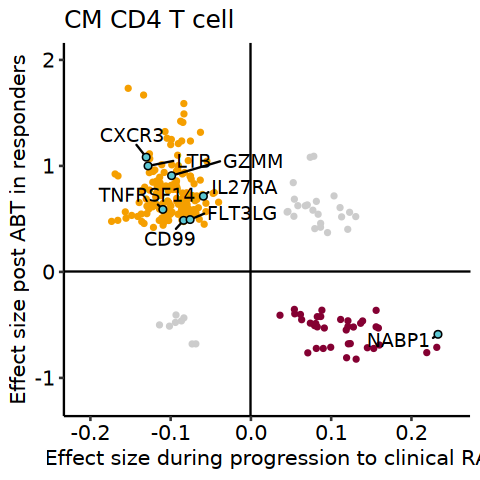

In [ ]:
# plot the significant genes
cell_type_plot <- "CM CD4 T cell"
abt_aim3_degs_comparison_sig %>%
    filter(cell_type == cell_type_plot) %>%
    group_by(direction) %>%
    tally()
p1 <- abt_aim3_degs_comparison_sig %>%
    filter(cell_type == cell_type_plot) %>%
    mutate(highlight_gene = if_else(gene %in% hightlight_genes, gene, NA)) %>%
    ggplot(aes(y = log2FoldChange, x = 365 * estimate)) +
    geom_point(aes(color = direction), size = 1) +
    ggrepel::geom_text_repel(aes(label = highlight_gene), min.segment.length = 0, nudge_x = 0.015, ) +
    geom_point(
        data = abt_aim3_degs_comparison_sig %>% filter(cell_type == cell_type_plot & gene %in% hightlight_genes),
        fill = "#5DC7D3", color = "black", size = 1.5, shape = 21, stroke = .5
    ) + # Yellow fill with black outline
    geom_vline(xintercept = 0) +
    geom_hline(yintercept = 0) +
    ylim(-1.2, 2) +
    xlim(-0.21, 0.25) +
    scale_color_manual(values = abt_colors) +
    theme_pubr() +
    guides(color = "none") +
    labs(
        title = cell_type_plot, x = "Effect size during progression to clinical RA",
        y = "Effect size post ABT in responders"
    )
p1
ggsave(file.path(fig_path, paste0(proj_name, "abecetpt_responder_Aim3_deg_", cell_type_plot, "_logfc_cor_plot_labeled.pdf")),
    width = 4, height = 4
)


In [ ]:
abt_aim3_degs_comparison_sig %>%
    filter(cell_type == "CM CD4 T cell") %>%
    filter(q_values_abt < 0.05 & q_values_aim3 < 0.05 & (aim3_direction == "aim3_up" & abt_direction == "abt_down"))


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values_abt,cell_type,effect,group,⋯,estimate,std.error,statistic,df,pvalue_aim3,q_values_aim3,sig,aim3_direction,abt_direction,direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<fct>
LUC7L3,679.9239,-0.5293458,0.1714175,-3.088049,0.0020147510,0.038709759,CM CD4 T cell,fixed,NA,⋯,0.0004351209,0.0001701003,2.558025,45.91334,0.013892538,0.04473971,AbtSig&Aim3Sig,aim3_up,abt_down,Increased during progression to RA& Decreased post ABT
SF3B1,4378.0218,-0.4627013,0.1261296,-3.668459,0.0002440173,0.009410519,CM CD4 T cell,fixed,NA,⋯,0.0003812325,0.0001381306,2.759942,42.82167,0.008473902,0.04077438,AbtSig&Aim3Sig,aim3_up,abt_down,Increased during progression to RA& Decreased post ABT
PRPF3,878.1049,-0.4486165,0.1290589,-3.476060,0.0005088383,0.016073059,CM CD4 T cell,fixed,NA,⋯,0.0003062412,0.0001004173,3.049685,45.93138,0.003795473,0.03466158,AbtSig&Aim3Sig,aim3_up,abt_down,Increased during progression to RA& Decreased post ABT
NABP1,989.9993,-0.5886575,0.1972668,-2.984067,0.0028444415,0.048950275,CM CD4 T cell,fixed,NA,⋯,0.0006385191,0.0002046917,3.119418,45.18839,0.003151955,0.03424478,AbtSig&Aim3Sig,aim3_up,abt_down,Increased during progression to RA& Decreased post ABT
NAIP,1185.5164,-0.7612663,0.2454766,-3.101176,0.0019275351,0.037697551,CM CD4 T cell,fixed,NA,⋯,0.0006002651,0.0002313428,2.594700,43.30072,0.012871136,0.04393876,AbtSig&Aim3Sig,aim3_up,abt_down,Increased during progression to RA& Decreased post ABT


### plot individual genes


In [ ]:
dds_resp


class: DESeqDataSet 
dim: 13608 14 
metadata(1): version
assays(4): counts mu H cooks
rownames(13608): TSPAN6 DPM1 ... AL031666.3 AC012510.1
rowData names(46): baseMean baseVar ... deviance maxCooks
colnames(14): R01_0M R01_3M ... R07_0M R07_3M
colData names(5): sample patient time response sizeFactor

In [ ]:
vst_resp <- vst(dds_resp, blind = FALSE)
vst_resp


class: DESeqTransform 
dim: 13608 14 
metadata(1): version
assays(1): ''
rownames(13608): TSPAN6 DPM1 ... AL031666.3 AC012510.1
rowData names(46): baseMean baseVar ... maxCooks dispFit
colnames(14): R01_0M R01_3M ... R07_0M R07_3M
colData names(5): sample patient time response sizeFactor

In [ ]:
NAIP_counts <- tibble(
    "Normalized counts" = assay(vst_resp)["NABP1", ],
    "time" = colData(vst_resp)$time,
    "patient" = colData(vst_resp)$patient
) %>%
    mutate(timepoint = recode(time, "0M" = "Pre-ABT", "3M" = "Post-ABT"))
NAIP_counts %>% head()


Normalized counts,time,patient,timepoint
<dbl>,<fct>,<fct>,<fct>
9.352057,0M,R01,Pre-ABT
8.916999,3M,R01,Post-ABT
9.611694,0M,R02,Pre-ABT
9.042851,3M,R02,Post-ABT
10.831938,0M,R03,Pre-ABT
9.835668,3M,R03,Post-ABT


In [ ]:
# NAIP_counts = plotCounts(vst_resp, 'NAIP', intgroup = c('time', 'patient'), returnData=TRUE)%>%
#     as_tibble()%>%
#     mutate(timepoint=recode(time, '0M'='Pre-treatment', '3M'='post-treatment'))
# NAIP_counts%>%head()


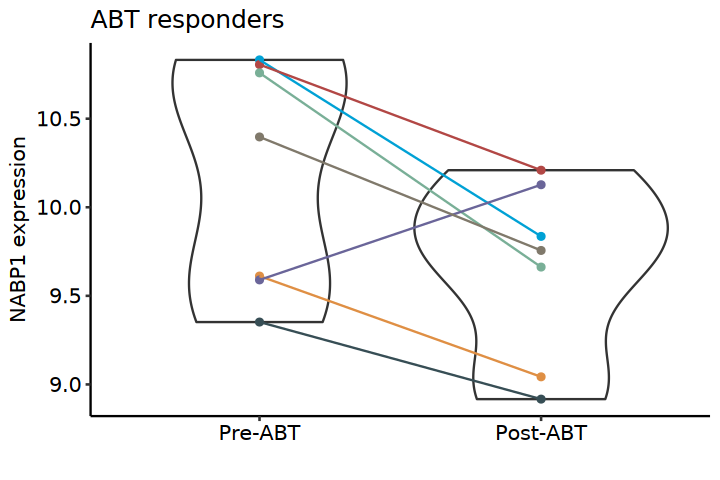

In [ ]:
p2 <- NAIP_counts %>%
        ggplot(aes(x = timepoint, y = `Normalized counts`)) +
        geom_violin(aes(), alpha = 0.6) +
        geom_point(aes(group = patient, color = patient)) +
        geom_line(aes(group = patient, color = patient)) +
        labs(title = "ABT responders", x = "", y = "NABP1 expression") +
        scale_color_manual(values = jama_color) +
        ggpubr::theme_pubr() +
        scale_shape_manual(values = c(1, 2)) +
        guides(color = "none", fill = "none")
p2
ggsave(file.path(fig_path, paste0(proj_name, "abecetpt_responder_NABP1_expression.pdf")),
        width = 3, height = 3
)
